## Sistema de Previsão com IA para Viagens Multimodais - EcoFusion
### Teste inicial com datasets públicos

Este notebook tem como objetivo realizar um teste exploratório e inicial ao sistema de previsão proposto para viagens multimodais, com foco nos três targets principais: custo, duração e emissões de CO2.

A ideia nesta fase não é implementar o sistema final completo, mas sim testar a viabilidade da arquitetura proposta com recurso a datasets públicos, perceber a estrutura dos dados disponíveis e avaliar se as abordagens definidas fazem sentido na prática.

### 1. Objetivo do notebook

Este notebook pretende:

1. identificar e preparar datasets públicos relevantes para o problema;
2. analisar as variáveis disponíveis e a sua adequação aos três targets;
3. testar outras fases do pipeline necessárias

### 2. Datasets públicos utilizados

Nesta secção serão identificados os datasets públicos escolhidos para o teste inicial. O objetivo não é encontrar já um dataset perfeito, mas sim reunir dados suficientemente úteis para validar a lógica do sistema.

Para cada dataset, interessa registar:

- a origem
- as variáveis disponíveis
- o target ou targets que permite estudar
- o tipo de transporte coberto
- as principais limitações

Datasets:
- **flights.csv**
- **airports.csv**
- **exchange_rates.csv**
- **conflict_oil_events.csv**
- **oil_jet_fuel_prices.csv**

### 3. Leitura inicial dos dados

Nesta fase será feita uma primeira observação dos datasets selecionados.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 3.1. Dataset base das viagens - flights.csv

In [5]:
df = pd.read_csv('flights.csv')

print(f"Dimensão do dataset: {df.shape[0]:,} registos x {df.shape[1]} colunas")

Dimensão do dataset: 317,260 registos x 11 colunas


##### 3.1.1. Colunas e tipos de variáveis

In [6]:
df.dtypes.to_frame(name="tipo").assign(
    exemplo=df.iloc[0]
).reset_index().rename(columns={"index":"coluna"})

,coluna,tipo,exemplo
0,Searched Date,object,2024-06-30
1,Departure Date,object,2024-07-16 23:48:00
2,Arrival Date,object,2024-07-17 15:03:00
3,Flight Lands Next Day,int64,1
4,Departure Airport,object,LAS
5,Arrival Airport,object,BOS
6,Number Of Stops,int64,1
7,Route,object,ATL
8,Airline,object,Spirit Airlines
9,Cabin,object,Economy


In [7]:
# converter Price para numérico
df['Price'] = df['Price'].str.replace('$', '', regex=False)\
                         .str.replace(',', '', regex=False)\
                         .astype(float)

# converter datas
df['Departure Date'] = pd.to_datetime(df['Departure Date'])
df['Arrival Date'] = pd.to_datetime(df['Arrival Date'])
df['Searched Date'] = pd.to_datetime(df['Searched Date'])

# calcular duração em minutos
df['Duration_min'] = (df['Arrival Date'] - df['Departure Date']).dt.total_seconds() / 60
df["Duration_min"] = df["Duration_min"].round().astype(int)

##### 3.1.2. Primeiros registos

In [8]:
df.head(5)

,Searched Date,Departure Date,Arrival Date,Flight Lands Next Day,Departure Airport,Arrival Airport,Number Of Stops,Route,Airline,Cabin,Price,Duration_min
0,2024-06-30,2024-07-16 23:48:00,2024-07-17 15:03:00,1,LAS,BOS,1,ATL,Spirit Airlines,Economy,83.0,915
1,2024-06-30,2024-07-16 09:34:00,2024-07-16 19:43:00,0,LAS,BOS,1,EWR,Spirit Airlines,Economy,100.0,609
2,2024-06-30,2024-07-16 23:48:00,2024-07-17 15:03:00,1,LAS,BOS,1,ATL,Spirit Airlines,Economy,78.0,915
3,2024-06-30,2024-07-16 08:30:00,2024-07-16 19:37:00,0,LAS,BOS,1,IAH,Spirit Airlines,Economy,100.0,667
4,2024-06-30,2024-07-16 07:00:00,2024-07-16 16:36:00,0,LAS,BOS,1,ORD,American Airlines,Basic Economy,148.0,576


##### 3.1.3. Estatísticas descritivas

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Searched Date,317260,NaN,NaN,NaN,2024-06-29 21:34:10.250267904,2024-06-27 00:00:00,2024-06-28 00:00:00,2024-06-30 00:00:00,2024-07-02 00:00:00,2024-07-03 00:00:00,NaN
Departure Date,317260,NaN,NaN,NaN,2024-08-03 09:09:24.735485184,2024-07-03 00:07:00,2024-07-12 11:46:00,2024-07-15 10:20:00,2024-07-24 07:00:00,2024-12-11 23:59:00,NaN
Arrival Date,317260,NaN,NaN,NaN,2024-08-03 18:35:05.311605504,2024-07-03 06:30:00,2024-07-12 21:18:00,2024-07-15 19:47:00,2024-07-24 15:14:00,2024-12-12 21:30:00,NaN
Flight Lands Next Day,317260.0,NaN,NaN,NaN,0.230246,0.0,0.0,0.0,0.0,1.0,0.420991
Departure Airport,317260,6,ORD,66806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival Airport,317260,6,ORD,65114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number Of Stops,317260.0,NaN,NaN,NaN,1.070144,0.0,1.0,1.0,1.0,3.0,0.559399
Route,278863,875,DEN,21608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airline,317260,46,United Airlines,108063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cabin,317260,26,Economy,103601,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### 3.1.4. Missing values

In [10]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "% total": (df.isnull().sum() / len(df) * 100).round(2)
}).query("missing > 0").sort_values("% total", ascending=False)

if missing.empty:
    print("Sem missing values.")
else:
    display(missing)

,missing,% total
Route,38397,12.1


Normal, porque nem todos os voos têm Route, isto é, nem todos os voos fazem 1 ou mais escalas.

##### 3.1.5. Distribuição das variáveis numéricas principais

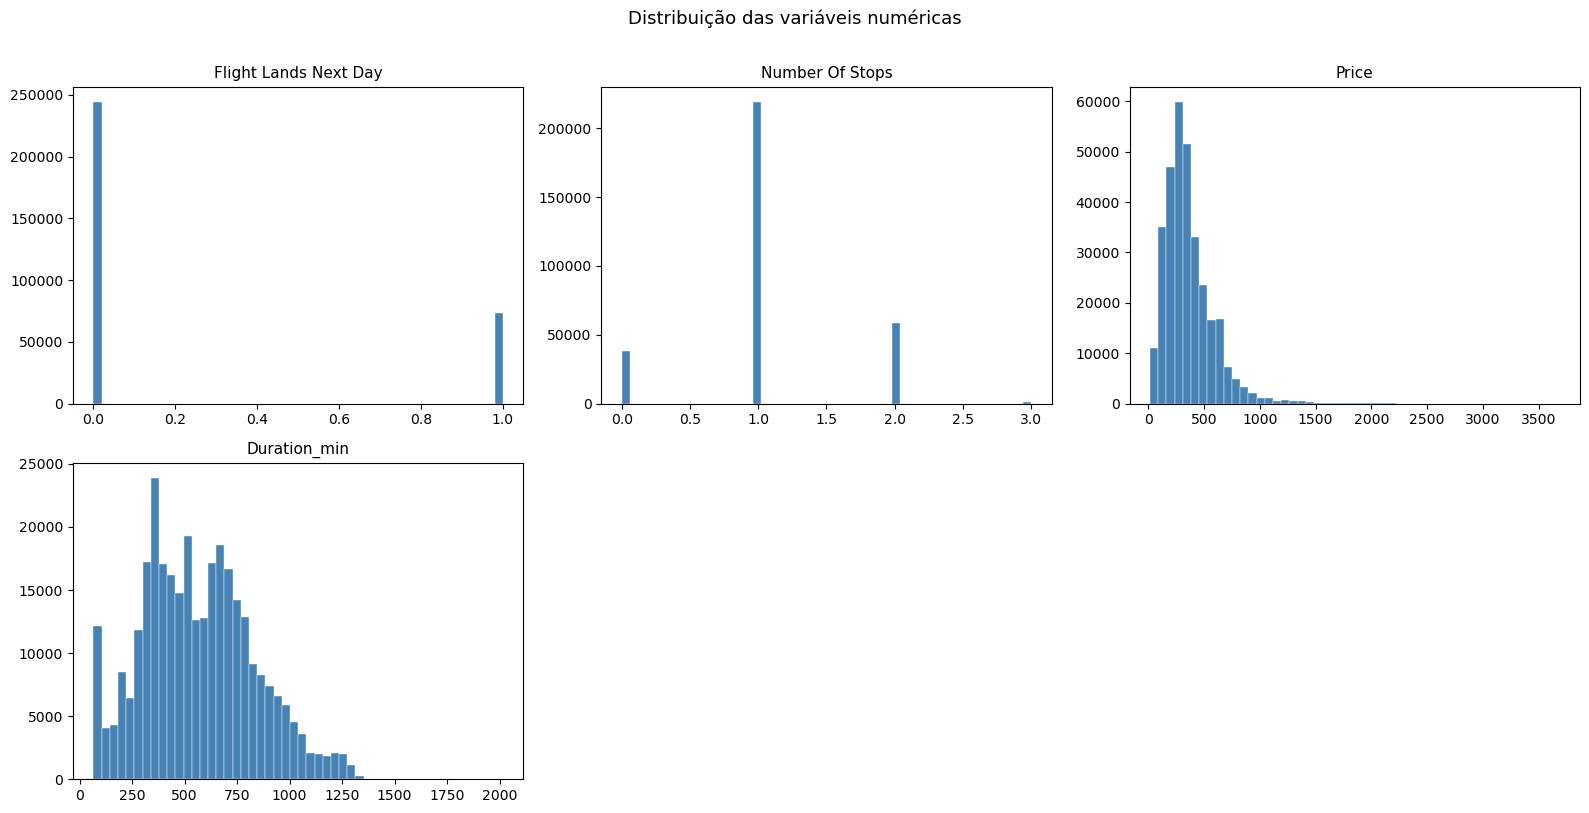

In [11]:
# ajusta as colunas conforme o que existir no dataset
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(nrows=(len(num_cols)+2)//3, ncols=3,
                         figsize=(16, 4 * ((len(num_cols)+2)//3)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição das variáveis numéricas", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


##### 3.1.6. Variáveis categóricas - valores únicos

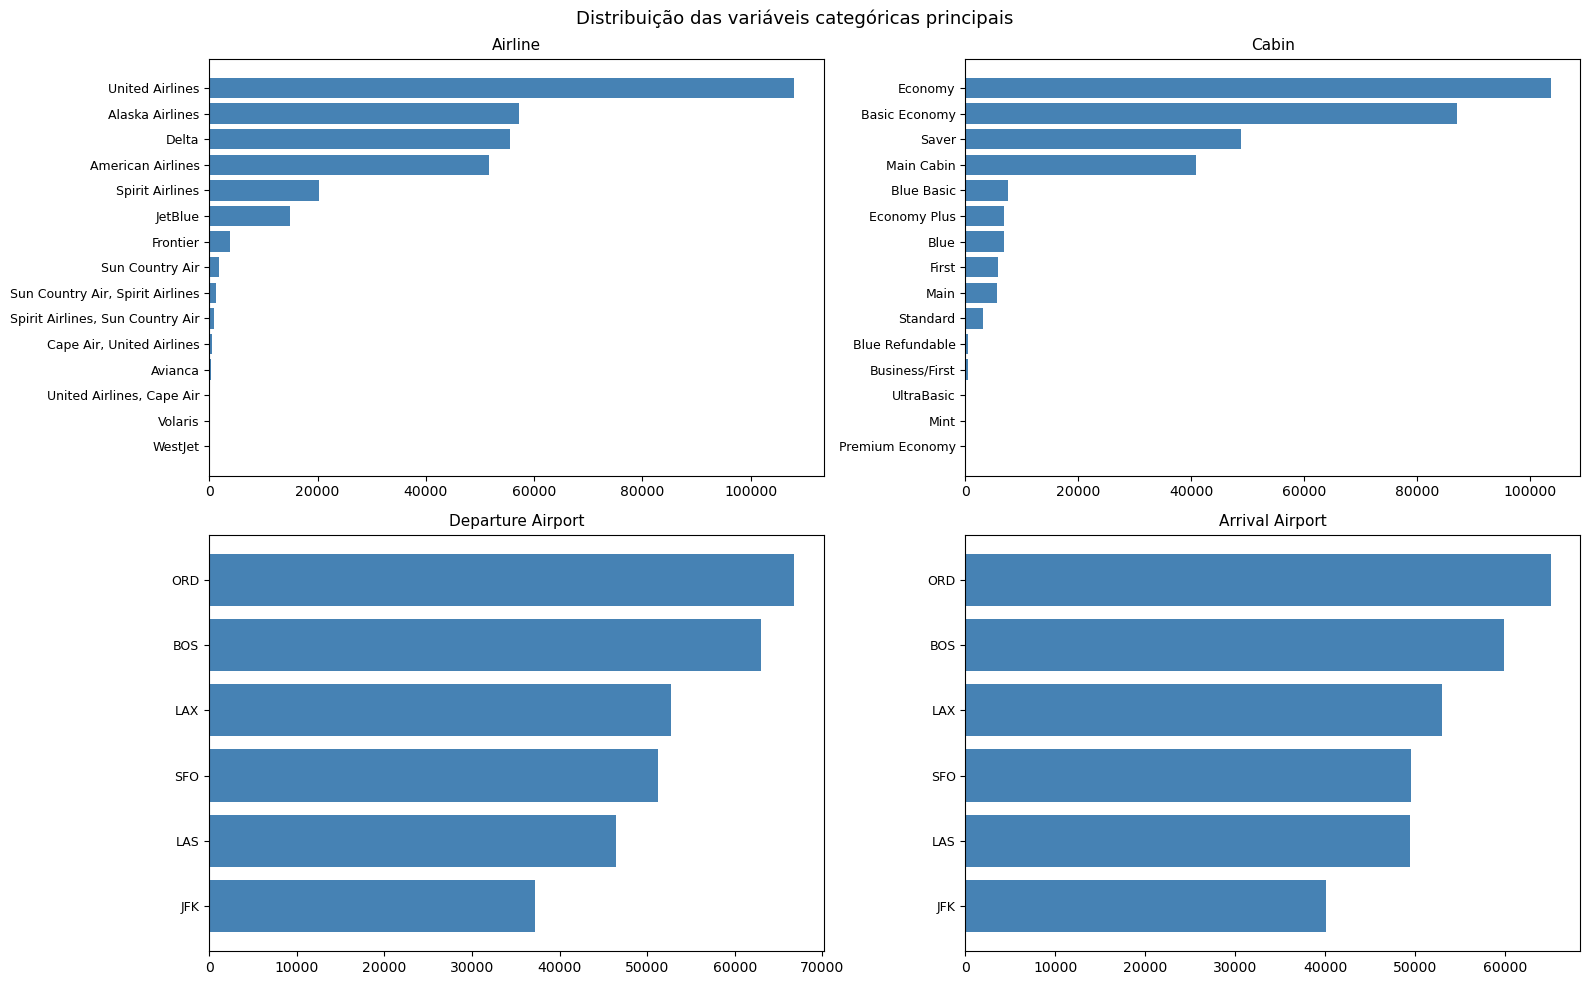

In [12]:
cat_cols = ['Airline', 'Cabin', 'Departure Airport', 'Arrival Airport']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(15)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Distribuição das variáveis categóricas principais', fontsize=13)
plt.tight_layout()
plt.show()

#### 3.2. Dataset de aeroportos - airports.csv

In [13]:
airports = pd.read_csv("airports.csv")

print(f"Dimensão do dataset: {airports.shape[0]:,} registos x {airports.shape[1]} colunas")

Dimensão do dataset: 85,285 registos x 19 colunas


##### 3.2.1. Colunas e tipos de variáveis

In [14]:
airports.dtypes.to_frame(name="tipo").assign(
    exemplo=airports.iloc[0]
).reset_index().rename(columns={"index":"coluna"})

,coluna,tipo,exemplo
0,id,int64,6523
1,ident,object,00A
2,type,object,heliport
3,name,object,Total RF Heliport
4,latitude_deg,float64,40.070985
5,longitude_deg,float64,-74.933689
6,elevation_ft,float64,11.0
7,continent,object,NaN
8,iso_country,object,US
9,iso_region,object,US-PA


##### 3.2.2. Primeiros registos

In [15]:
airports.head(5)

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


##### 3.2.3. Missing values

In [16]:
missing_airports = pd.DataFrame({
    "missing": airports.isnull().sum(),
    "% total": (airports.isnull().sum() / len(airports) * 100).round(2)
}).query("missing > 0").sort_values("% total", ascending=False)

if missing_airports.empty:
    print("Sem missing values.")
else:
    display(missing_airports)

,missing,% total
home_link,80595,94.50
iata_code,76229,89.38
icao_code,75281,88.27
wikipedia_link,68595,80.43
keywords,64011,75.06
local_code,49224,57.72
gps_code,41110,48.20
continent,39549,46.37
elevation_ft,14782,17.33
municipality,4711,5.52


##### 3.2.4. Cobertura geográfica - aeroportos presentes no flights.csv

In [17]:
airports_flights = set(df["Departure Airport"].unique()) | set(df["Arrival Airport"].unique())

# a coluna correta no airports.csv é iata_code
airports_csv = set(airports["iata_code"].dropna().unique())

matched = airports_flights & airports_csv
unmatched = airports_flights - airports_csv

print(f"Aeroportos únicos em flights.csv: {len(airports_flights)}")
print(f"Presentes em airports.csv: {len(matched)} ({len(matched)/len(airports_flights)*100:.0f}%)")
if unmatched:
    print(f"Não encontrados em airports.csv: {unmatched}")

Aeroportos únicos em flights.csv: 6
Presentes em airports.csv: 6 (100%)


#### 3.3. Dataset de preços de combustível e petróleo - oil_jet_fuel_prices.csv

In [18]:
oil = pd.read_csv("oil_jet_fuel_prices.csv")
print(f"Dimensao: {oil.shape}")
oil.head(3)

Dimensao: (87, 12)


,month,conflict_phase,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd,jet_fuel_usd_per_gallon,wti_crude_usd_barrel,opec_production_mbd,us_strategic_reserve_mbl,strait_hormuz_disrupted,yoy_brent_change_pct,data_source
0,2019-01,Pre-Pandemic Baseline,63.00,74.58,11.58,1.801,61.70,27.00,559.3,No,NaN,EIA / Platts / IATA
1,2019-02,Pre-Pandemic Baseline,67.61,81.72,14.11,1.882,62.77,28.00,389.6,No,NaN,EIA / Platts / IATA
2,2019-03,Pre-Pandemic Baseline,65.86,76.87,11.01,1.865,62.64,27.51,591.9,No,NaN,EIA / Platts / IATA


In [19]:
oil.dtypes.to_frame(name="tipo").assign(exemplo=oil.iloc[0]).reset_index().rename(columns={"index":"coluna"})

,coluna,tipo,exemplo
0,month,object,2019-01
1,conflict_phase,object,Pre-Pandemic Baseline
2,brent_crude_usd_barrel,float64,63.0
3,jet_fuel_usd_barrel,float64,74.58
4,refinery_margin_usd,float64,11.58
5,jet_fuel_usd_per_gallon,float64,1.801
6,wti_crude_usd_barrel,float64,61.7
7,opec_production_mbd,float64,27.0
8,us_strategic_reserve_mbl,float64,559.3
9,strait_hormuz_disrupted,object,No


In [20]:
missing_oil = pd.DataFrame({
    "missing": oil.isnull().sum(),
    "% total": (oil.isnull().sum() / len(oil) * 100).round(2)
}).query("missing > 0").sort_values("% total", ascending=False)
print("Sem missing values." if missing_oil.empty else "")
if not missing_oil.empty: display(missing_oil)

,missing,% total
yoy_brent_change_pct,12,13.79


#### 3.4. Dataset de eventos de conflito - conflict_oil_events.csv

In [21]:
conflicts = pd.read_csv("conflict_oil_events.csv")
print(f"Dimensao: {conflicts.shape}")
conflicts.head(3)

Dimensao: (36, 14)


,event_date,event_type,event_description,location,severity,brent_before_usd,brent_after_usd,oil_price_change_pct,airfare_impact_pct,days_since_prev_event,conflict_phase,flight_cancellations_est,airspace_closures_countries,data_source
0,2019-04-11,Political,Venezuela sanctions escalate; OPEC+ extends cuts,Global,Medium,67.5,72.3,7.1,2.5,NaN,Pre-Pandemic Baseline,1500,1,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...
1,2019-06-13,Military,Tanker attacks in Gulf of Oman — Iran blamed,Strait of Hormuz,High,60.5,65.2,7.8,3.1,63.0,Pre-Pandemic Baseline,1671,2,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...
2,2019-09-14,Military,Houthi drone strike hits Saudi Aramco faciliti...,"Abqaiq, Saudi Arabia",Very High,60.2,71.5,18.7,6.2,93.0,Pre-Pandemic Baseline,2737,3,Reuters / Bloomberg / Al Jazeera / IATA / EIA ...


In [22]:
conflicts.dtypes.to_frame(name="tipo").assign(exemplo=conflicts.iloc[0]).reset_index().rename(columns={"index":"coluna"})

,coluna,tipo,exemplo
0,event_date,object,2019-04-11
1,event_type,object,Political
2,event_description,object,Venezuela sanctions escalate; OPEC+ extends cuts
3,location,object,Global
4,severity,object,Medium
5,brent_before_usd,float64,67.5
6,brent_after_usd,float64,72.3
7,oil_price_change_pct,float64,7.1
8,airfare_impact_pct,float64,2.5
9,days_since_prev_event,float64,NaN


In [23]:
missing_c = pd.DataFrame({
    "missing": conflicts.isnull().sum(),
    "% total": (conflicts.isnull().sum() / len(conflicts) * 100).round(2)
}).query("missing > 0").sort_values("% total", ascending=False)
print("Sem missing values." if missing_c.empty else "")
if not missing_c.empty: display(missing_c)

,missing,% total
days_since_prev_event,1,2.78


#### 3.5. Dataset de taxas de câmbio - exchange_rates.csv

In [24]:
fx = pd.read_csv("exchange_rates.csv")
print(f"Dimensao: {fx.shape}")
fx.head(3)

Dimensao: (4473, 6)


,Date,Close,High,Low,Open,currency_pair
0,1/1/2020,1.122083,1.122838,1.115947,1.122083,EUR/USD
1,1/2/2020,1.122083,1.122712,1.116682,1.121894,EUR/USD
2,1/3/2020,1.117144,1.118068,1.112570,1.117081,EUR/USD


In [25]:
fx.dtypes.to_frame(name="tipo").assign(exemplo=fx.iloc[0]).reset_index().rename(columns={"index":"coluna"})

,coluna,tipo,exemplo
0,Date,object,1/1/2020
1,Close,float64,1.122083
2,High,float64,1.122838
3,Low,float64,1.115947
4,Open,float64,1.122083
5,currency_pair,object,EUR/USD


In [26]:
# verificar pares de moeda disponíveis
print("Pares de moeda disponíveis:")
print(fx["currency_pair"].value_counts())

Pares de moeda disponíveis:
currency_pair
EUR/USD    1491
GBP/USD    1491
USD/JPY    1491
Name: count, dtype: int64


In [27]:
missing_fx = pd.DataFrame({
    "missing": fx.isnull().sum(),
    "% total": (fx.isnull().sum() / len(fx) * 100).round(2)
}).query("missing > 0").sort_values("% total", ascending=False)
print("Sem missing values." if missing_fx.empty else "")
if not missing_fx.empty: display(missing_fx)

Sem missing values.


### 4. Pré-processamento e feature engineering

Nesta secção é construído o dataset conjunto pronto para modelação, a partir do join entre os datasets e da geração das features necessárias para prever custo e duração.

#### 4.1. Construção das features de rota, temporais e de viagem

Esta secção cobre:
- join com `airports.csv` para obter coordenadas de origem e destino;
- cálculo da distância entre aeroportos via fórmula de Haversine;
- features temporais derivadas das datas (antecedência, dia da semana, mês, hora);
- limpeza e normalização da coluna Cabin;
- encoding das variáveis categóricas;
- dataset final consolidado.

##### 4.1.1. Join com airports.csv - coordenadas de origem e destino

In [28]:
# selecionar só as colunas necessárias do airports.csv
airports_coords = airports[["iata_code", "latitude_deg", "longitude_deg", "name", "iso_country"]].dropna(subset=["iata_code"])

# join para aeroporto de origem
df = df.merge(
    airports_coords.rename(columns={
        "iata_code": "Departure Airport",
        "latitude_deg": "dep_lat",
        "longitude_deg": "dep_lon",
        "name": "dep_airport_name",
        "iso_country": "dep_country"
    }),
    on="Departure Airport", how="left"
)

# join para aeroporto de destino
df = df.merge(
    airports_coords.rename(columns={
        "iata_code": "Arrival Airport",
        "latitude_deg": "arr_lat",
        "longitude_deg": "arr_lon",
        "name": "arr_airport_name",
        "iso_country": "arr_country"
    }),
    on="Arrival Airport", how="left"
)

print(f"Shape apos join: {df.shape}")
df[["Departure Airport", "dep_lat", "dep_lon", "Arrival Airport", "arr_lat", "arr_lon"]].head(3)

Shape apos join: (317260, 20)


,Departure Airport,dep_lat,dep_lon,Arrival Airport,arr_lat,arr_lon
0,LAS,36.083361,-115.151817,BOS,42.36197,-71.0079
1,LAS,36.083361,-115.151817,BOS,42.36197,-71.0079
2,LAS,36.083361,-115.151817,BOS,42.36197,-71.0079


##### 4.1.2. Distância entre aeroportos - fórmula de Haversine

Distância em linha reta na superfície da Terra:

$$
d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)
$$

In [29]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raio da Terra em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["dep_lat"].values, df["dep_lon"].values,
    df["arr_lat"].values, df["arr_lon"].values
)

print(f"Distancia minima: {df['distance_km'].min():.0f} km")
print(f"Distancia media:  {df['distance_km'].mean():.0f} km")
print(f"Distancia maxima: {df['distance_km'].max():.0f} km")
df[["Departure Airport", "Arrival Airport", "distance_km"]].drop_duplicates().sort_values("distance_km")

Distancia minima: 300 km
Distancia media:  3052 km
Distancia maxima: 4341 km


,Departure Airport,Arrival Airport,distance_km
2268,JFK,BOS,299.895335
6878,BOS,JFK,299.895335
1996,LAX,LAS,380.229429
998,LAS,LAX,380.229429
3180,LAX,SFO,543.244922
1826,SFO,LAX,543.244922
1925,SFO,LAS,664.805366
8978,LAS,SFO,664.805366
6569,ORD,JFK,1187.809234
1771,JFK,ORD,1187.809234


##### 4.1.3. Features temporais

In [30]:
# antecedencia da compra em dias
df["lead_time_days"]  = (df["Departure Date"] - df["Searched Date"]).dt.days

# features da data de partida
df["dep_hour"]        = df["Departure Date"].dt.hour
df["dep_day_of_week"] = df["Departure Date"].dt.dayofweek  # 0=segunda, 6=domingo
df["dep_month"]       = df["Departure Date"].dt.month
df["dep_is_weekend"]  = df["dep_day_of_week"].isin([5, 6]).astype(int)

print("Features temporais criadas:")
df[["lead_time_days", "dep_hour", "dep_day_of_week", "dep_month", "dep_is_weekend", "Duration_min"]].describe()

Features temporais criadas:


,lead_time_days,dep_hour,dep_day_of_week,dep_month,dep_is_weekend,Duration_min
count,317260.000000,317260.000000,317260.000000,317260.000000,317260.000000,317260.000000
mean,33.981066,11.613021,2.602622,7.611016,0.171887,565.676269
std,45.069549,5.082038,1.640586,1.458036,0.377283,265.582554
min,6.000000,0.000000,0.000000,7.000000,0.000000,66.000000
25%,12.000000,7.000000,2.000000,7.000000,0.000000,364.000000
50%,15.000000,11.000000,2.000000,7.000000,0.000000,541.000000
75%,22.000000,15.000000,4.000000,7.000000,0.000000,739.000000
max,167.000000,23.000000,6.000000,12.000000,1.000000,2016.000000


In [31]:
df.head(5)

,Searched Date,Departure Date,Arrival Date,Flight Lands Next Day,Departure Airport,Arrival Airport,Number Of Stops,Route,Airline,Cabin,...,arr_lat,arr_lon,arr_airport_name,arr_country,distance_km,lead_time_days,dep_hour,dep_day_of_week,dep_month,dep_is_weekend
0,2024-06-30,2024-07-16 23:48:00,2024-07-17 15:03:00,1,LAS,BOS,1,ATL,Spirit Airlines,Economy,...,42.36197,-71.0079,Boston Logan International Airport,US,3822.306165,16,23,1,7,0
1,2024-06-30,2024-07-16 09:34:00,2024-07-16 19:43:00,0,LAS,BOS,1,EWR,Spirit Airlines,Economy,...,42.36197,-71.0079,Boston Logan International Airport,US,3822.306165,16,9,1,7,0
2,2024-06-30,2024-07-16 23:48:00,2024-07-17 15:03:00,1,LAS,BOS,1,ATL,Spirit Airlines,Economy,...,42.36197,-71.0079,Boston Logan International Airport,US,3822.306165,16,23,1,7,0
3,2024-06-30,2024-07-16 08:30:00,2024-07-16 19:37:00,0,LAS,BOS,1,IAH,Spirit Airlines,Economy,...,42.36197,-71.0079,Boston Logan International Airport,US,3822.306165,16,8,1,7,0
4,2024-06-30,2024-07-16 07:00:00,2024-07-16 16:36:00,0,LAS,BOS,1,ORD,American Airlines,Basic Economy,...,42.36197,-71.0079,Boston Logan International Airport,US,3822.306165,16,7,1,7,0


##### 4.1.4. Limpeza da coluna Cabin

In [32]:
print("Valores unicos de Cabin antes da limpeza:")
print(df["Cabin"].value_counts().to_string())

Valores unicos de Cabin antes da limpeza:
Cabin
Economy                              103601
Basic Economy                         87052
Saver                                 48768
Main Cabin                            40852
Blue Basic                             7569
Economy Plus                           6853
Blue                                   6753
First                                  5706
Main                                   5620
Standard                               3141
Blue Refundable                         476
Business/First                          403
UltraBasic                              123
Mint                                     83
Premium Economy                          83
Main Cabin Flex                          46
PorterClassic Basic                      41
BizFare                                  34
No Flex Fare                             30
Main Cabin Basic                          8
Comfort +                                 6
Main Select                 

In [33]:
# normalizar: lowercase, remover espacos
df["cabin_clean"] = df["Cabin"].str.lower().str.strip()

# agrupar variacoes no mesmo tipo - ajustado conforme os valores encontrados acima
cabin_map = {
    # economy
    "economy":                      "economy",
    "basic economy":                "economy",
    "main cabin":                   "economy",
    "main cabin basic":             "economy",
    "main cabin flex":              "economy",
    "main select":                  "economy",
    "main":                         "economy",
    "saver":                        "economy",
    "standard":                     "economy",
    "blue":                         "economy",
    "blue basic":                   "economy",
    "blue refundable":              "economy",
    "ultrabasic":                   "economy",
    "no flex fare":                 "economy",
    "porterclassic basic":          "economy",
    "discount":                     "economy",
    "economy (fully refundable)":   "economy",
    "mixed":                        "economy",
    # premium economy
    "economy plus":                 "premium_economy",
    "comfort +":                    "premium_economy",
    "premium economy":              "premium_economy",
    # business / first
    "first":                        "first",
    "business/first":               "first",
    "business/first (fully refundable)": "first",
    "mint":                         "business",
    "bizfare":                      "business",
}
df["cabin_clean"] = df["cabin_clean"].map(cabin_map).fillna(df["cabin_clean"])

print("Valores apos limpeza:")
print(df["cabin_clean"].value_counts())

Valores apos limpeza:
cabin_clean
economy            304089
premium_economy      6942
first                6112
business              117
Name: count, dtype: int64


##### 4.1.5. Encoding das variáveis categóricas

In [34]:
from sklearn.preprocessing import LabelEncoder

# label encoding para companhia (muitas categorias, sem ordem)
le_airline = LabelEncoder()
df["airline_enc"] = le_airline.fit_transform(df["Airline"].astype(str))

# label encoding para aeroportos de origem e destino
# atribui um numero inteiro a cada aeroporto sem usar o target como referencia
# evita data leakage - o target encoding correto sera feito dentro do walk-forward
le_dep = LabelEncoder()
le_arr = LabelEncoder()
df["dep_airport_enc"] = le_dep.fit_transform(df["dep_airport_name"])
df["arr_airport_enc"] = le_arr.fit_transform(df["arr_airport_name"])

# one-hot encoding apenas para cabine (4 categorias — viavel)
df = pd.get_dummies(df, columns=["cabin_clean"], drop_first=False)

cabin_cols = [c for c in df.columns if "cabin_clean_" in c]

print(f"Shape apos encoding: {df.shape}")
print(f"Aeroporto origem - mapeamento: {dict(zip(le_dep.classes_, le_dep.transform(le_dep.classes_)))}")
print(f"Aeroporto destino - mapeamento: {dict(zip(le_arr.classes_, le_arr.transform(le_arr.classes_)))}")
print(f"Colunas de cabine: {cabin_cols}")

Shape apos encoding: (317260, 33)
Aeroporto origem - mapeamento: {'Boston Logan International Airport': np.int64(0), "Chicago O'Hare International Airport": np.int64(1), 'Harry Reid International Airport': np.int64(2), 'John F. Kennedy International Airport': np.int64(3), 'Los Angeles International Airport': np.int64(4), 'San Francisco International Airport': np.int64(5)}
Aeroporto destino - mapeamento: {'Boston Logan International Airport': np.int64(0), "Chicago O'Hare International Airport": np.int64(1), 'Harry Reid International Airport': np.int64(2), 'John F. Kennedy International Airport': np.int64(3), 'Los Angeles International Airport': np.int64(4), 'San Francisco International Airport': np.int64(5)}
Colunas de cabine: ['cabin_clean_business', 'cabin_clean_economy', 'cabin_clean_first', 'cabin_clean_premium_economy']


##### 4.1.6. Dataset final para modelação

In [35]:
# lista intermédia de features (antes dos datasets externos)
# usada só para referência — a lista final fica no 4.2.6
cabin_cols = [c for c in df.columns if "cabin_clean_" in c]

features_custo_base = [
    "distance_km", "Number Of Stops", "lead_time_days",
    "dep_hour", "dep_day_of_week", "dep_month", "dep_is_weekend",
    "Flight Lands Next Day", "airline_enc",
    "dep_airport_enc", "arr_airport_enc",
] + cabin_cols

features_duracao_base = [
    "distance_km", "Number Of Stops",
    "dep_hour", "dep_day_of_week", "dep_month", "dep_is_weekend",
    "Flight Lands Next Day", "airline_enc",
    "dep_airport_enc", "arr_airport_enc",
] + cabin_cols

print(f"Features custo base:   {len(features_custo_base)}")
print(f"Features duracao base: {len(features_duracao_base)}")

Features custo base:   15
Features duracao base: 14


#### 4.2. Integração dos datasets externos

Esta secção integra variáveis contextuais externas no dataset principal, todas ligadas pela chave `year_month` (ano e mês da data de partida do voo). Todos os voos do mesmo mês recebem os mesmos valores externos.

##### 4.2.1. Preparação da chave de join - year_month

In [36]:
# criar chave de join ano-mês no dataset principal
df["year_month"] = df["Departure Date"].dt.to_period("M").astype(str)

print("Intervalo de datas no flights.csv:")
print(f"  de: {df['year_month'].min()}")
print(f"  até: {df['year_month'].max()}")
print(f"  meses únicos: {df['year_month'].nunique()}")

Intervalo de datas no flights.csv:
  de: 2024-07
  até: 2024-12
  meses únicos: 3


##### 4.2.2. Join com preços de combustível - oil_jet_fuel_prices.csv

Liga cada voo ao preço do petróleo (brent) e do jet fuel do mês em que ocorreu, bem como à margem de refinação - diferença entre o preço do petróleo bruto e o custo de o transformar em jet fuel, que é um indicador de pressão nos custos operacionais das companhias aéreas.

In [37]:
oil["year_month"] = pd.to_datetime(oil["month"], format="%Y-%m").dt.to_period("M").astype(str)

oil_cols = ["year_month", "brent_crude_usd_barrel", "jet_fuel_usd_barrel",
            "jet_fuel_usd_per_gallon", "refinery_margin_usd", "conflict_phase"]

df = df.merge(oil[oil_cols], on="year_month", how="left")

print(f"Shape apos join combustivel: {df.shape}")
print(f"Missing em jet_fuel_usd_barrel: {df['jet_fuel_usd_barrel'].isnull().sum()}")
df[["year_month","brent_crude_usd_barrel","jet_fuel_usd_barrel",
    "refinery_margin_usd","conflict_phase"]].drop_duplicates().sort_values("year_month")

Shape apos join combustivel: (317260, 39)
Missing em jet_fuel_usd_barrel: 0


,year_month,brent_crude_usd_barrel,jet_fuel_usd_barrel,refinery_margin_usd,conflict_phase
0,2024-07,80.40,93.98,13.58,Gaza-Israel Conflict
1294,2024-09,79.27,90.70,11.43,Gaza-Israel Conflict
1826,2024-12,81.38,93.08,11.70,Pre-Iran Escalation


##### 4.2.3. Join com eventos de conflito - conflict_oil_events.csv

O dataset tem 36 eventos pontuais de conflito com datas específicas. O código agrega por mês - se houve algum evento num mês, todos os voos desse mês ficam com `conflict_active = 1`. São também integrados o número estimado de cancelamentos de voos e o número de países com espaço aéreo fechado nesse mês.

In [38]:
conflicts["year_month"] = pd.to_datetime(conflicts["event_date"]).dt.to_period("M").astype(str)

conflict_monthly = conflicts.groupby("year_month").agg(
    flight_cancellations_est=("flight_cancellations_est", "sum"),
    airspace_closures=("airspace_closures_countries", "sum"),
    airfare_impact_pct=("airfare_impact_pct", "mean"),
).reset_index()
conflict_monthly["conflict_active"] = 1

df = df.merge(conflict_monthly, on="year_month", how="left")

df["conflict_active"] = df["conflict_active"].fillna(0).astype(int)
df["flight_cancellations_est"] = df["flight_cancellations_est"].fillna(0)
df["airspace_closures"] = df["airspace_closures"].fillna(0)
df["airfare_impact_pct"] = df["airfare_impact_pct"].fillna(0)

print(f"Shape apos join conflitos: {df.shape}")
print(f"Meses com conflito activo: {df['conflict_active'].value_counts().to_dict()}")

Shape apos join conflitos: (317260, 43)
Meses com conflito activo: {0: 287867, 1: 29393}


##### 4.2.4. Conversão do preço para euros - exchange_rates.csv

O preço original está em dólares americanos (USD). Para o sistema final - que opera em contexto europeu - o target é convertido para euros usando a taxa de câmbio EUR/USD média do mês da compra. A taxa EUR/USD indica quantos dólares vale 1 euro, por isso a conversão é `price_eur = Price / eur_usd_rate`.

In [39]:
# filtrar EUR/USD e calcular taxa média mensal
fx["Date"] = pd.to_datetime(fx["Date"])
fx["year_month"] = fx["Date"].dt.to_period("M").astype(str)

fx_eur_usd = fx[fx["currency_pair"] == "EUR/USD"].copy()
fx_monthly = fx_eur_usd.groupby("year_month")["Close"].mean().reset_index()
fx_monthly.rename(columns={"Close": "eur_usd_rate"}, inplace=True)

df = df.merge(fx_monthly, on="year_month", how="left")
df["price_eur"] = (df["Price"] / df["eur_usd_rate"]).round(2)

print(f"Shape apos join cambio: {df.shape}")
print(f"Missing em price_eur: {df['price_eur'].isnull().sum()}")
df[["year_month","Price","eur_usd_rate","price_eur"]].drop_duplicates("year_month").sort_values("year_month")

Shape apos join cambio: (317260, 45)
Missing em price_eur: 0


,year_month,Price,eur_usd_rate,price_eur
0,2024-07,83.0,1.084147,76.56
1294,2024-09,89.0,1.110223,80.16
1826,2024-12,30.0,1.047404,28.64


#### 4.3. Dataset final consolidado com todas as features

In [40]:
cabin_cols = [c for c in df.columns if "cabin_clean_" in c]

# Cenario B: todas as features previstas no sistema (sem filtragem)
# inclui variaveis externas (combustivel, conflito, cambio) que representam
# o sistema final com dados de varios anos
features_custo_all = [
    # rota e viagem
    "distance_km", "Number Of Stops", "lead_time_days",
    "airline_enc", "Flight Lands Next Day",
    # aeroportos (label encoding)
    "dep_airport_enc", "arr_airport_enc",
    # cabine (one-hot)
] + cabin_cols + [
    # temporais
    "dep_hour", "dep_day_of_week", "dep_month", "dep_is_weekend",
    # combustivel
    "brent_crude_usd_barrel", "jet_fuel_usd_barrel",
    "refinery_margin_usd",
    # cambio
    "eur_usd_rate",
    # conflito
    "conflict_active", "flight_cancellations_est",
    "airspace_closures", "airfare_impact_pct",
]

features_duracao_all = [
    # rota e viagem
    "distance_km", "Number Of Stops", "airline_enc", "Flight Lands Next Day",
    # aeroportos (label encoding)
    "dep_airport_enc", "arr_airport_enc",
    # cabine (one-hot)
] + cabin_cols + [
    # temporais
    "dep_hour", "dep_day_of_week", "dep_month", "dep_is_weekend",
    # conflito
    "conflict_active", "flight_cancellations_est", "airspace_closures",
]

target_custo   = "price_eur"
target_duracao = "Duration_min"

df_model = df.dropna(subset=[target_custo, target_duracao]).copy()

print(f"Registos para modelacao: {len(df_model):,}")
print(f"Features custo:   {len(features_custo_all)}")
print(f"Features duracao: {len(features_duracao_all)}")

Registos para modelacao: 317,260
Features custo:   23
Features duracao: 17


In [41]:
features_custo_all

['distance_km',
 'Number Of Stops',
 'lead_time_days',
 'airline_enc',
 'Flight Lands Next Day',
 'dep_airport_enc',
 'arr_airport_enc',
 'cabin_clean_business',
 'cabin_clean_economy',
 'cabin_clean_first',
 'cabin_clean_premium_economy',
 'dep_hour',
 'dep_day_of_week',
 'dep_month',
 'dep_is_weekend',
 'brent_crude_usd_barrel',
 'jet_fuel_usd_barrel',
 'refinery_margin_usd',
 'eur_usd_rate',
 'conflict_active',
 'flight_cancellations_est',
 'airspace_closures',
 'airfare_impact_pct']

In [42]:
features_duracao_all

['distance_km',
 'Number Of Stops',
 'airline_enc',
 'Flight Lands Next Day',
 'dep_airport_enc',
 'arr_airport_enc',
 'cabin_clean_business',
 'cabin_clean_economy',
 'cabin_clean_first',
 'cabin_clean_premium_economy',
 'dep_hour',
 'dep_day_of_week',
 'dep_month',
 'dep_is_weekend',
 'conflict_active',
 'flight_cancellations_est',
 'airspace_closures']

### 5. Seleção de features

Antes de treinar os modelos, é importante confirmar quais as features que têm relação real com cada target. Entrar nos modelos com features irrelevantes ou redundantes prejudica a generalização e dificulta a interpretação dos resultados.

São usadas três técnicas complementares:

- **Correlação de Pearson** - mede a relação linear individual de cada feature com o target. Rápida mas não captura relações não-lineares.
- **LASSO** - regressão com penalização L1 que força coeficientes de features irrelevantes a zero. Considera todas as features em simultâneo, ao contrário do Pearson.
- **Feature importance do Random Forest** - mede a contribuição de cada feature para reduzir o erro. Captura relações não-lineares e interações entre features.

O critério de decisão final é: **uma feature é mantida se for selecionada por pelo menos 2 dos 3 métodos**.

#### 5.1. Correlação de Pearson

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# usar features_all para a selecao - avaliar todas as features candidatas
df_sel = df_model.dropna(subset=features_custo_all + features_duracao_all).copy()

X_custo   = df_sel[features_custo_all]
X_duracao = df_sel[features_duracao_all]
y_custo   = df_sel["price_eur"]
y_duracao = df_sel["Duration_min"]

print(f"Registos usados na selecao: {len(df_sel):,}")

Registos usados na selecao: 317,260


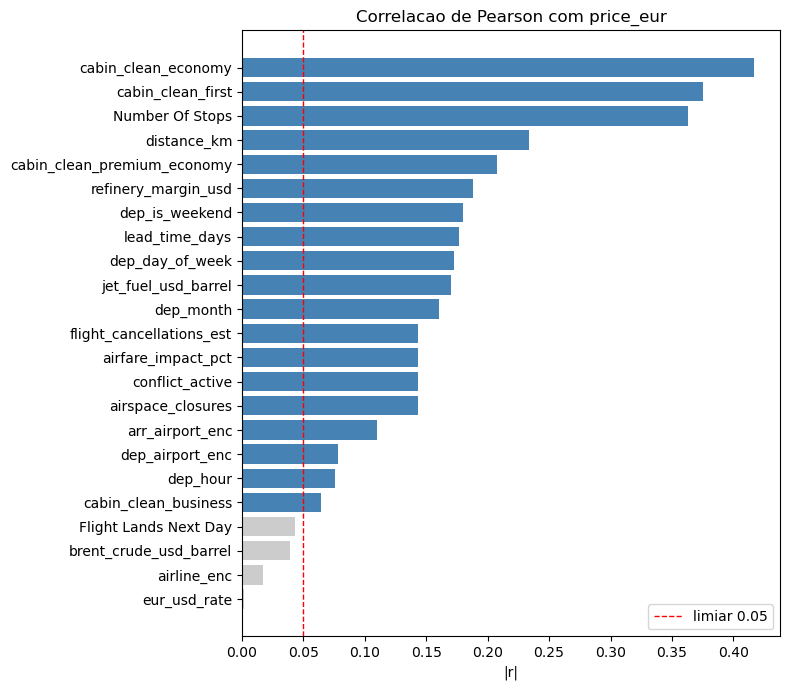

Features selecionadas pelo Pearson (custo): 19
['Number Of Stops', 'airfare_impact_pct', 'airspace_closures', 'arr_airport_enc', 'cabin_clean_business', 'cabin_clean_economy', 'cabin_clean_first', 'cabin_clean_premium_economy', 'conflict_active', 'dep_airport_enc', 'dep_day_of_week', 'dep_hour', 'dep_is_weekend', 'dep_month', 'distance_km', 'flight_cancellations_est', 'jet_fuel_usd_barrel', 'lead_time_days', 'refinery_margin_usd']


In [44]:
# correlacao de Pearson - custo
pearson_custo = X_custo.corrwith(y_custo).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue" if v >= 0.05 else "#cccccc" for v in pearson_custo.values]
ax.barh(pearson_custo.index[::-1], pearson_custo.values[::-1], color=colors[::-1])
ax.axvline(0.05, color="red", linestyle="--", linewidth=1, label="limiar 0.05")
ax.set_title("Correlacao de Pearson com price_eur", fontsize=12)
ax.set_xlabel("|r|")
ax.legend()
plt.tight_layout()
plt.show()

pearson_custo_selected = set(pearson_custo[pearson_custo >= 0.05].index)
print(f"Features selecionadas pelo Pearson (custo): {len(pearson_custo_selected)}")
print(sorted(pearson_custo_selected))

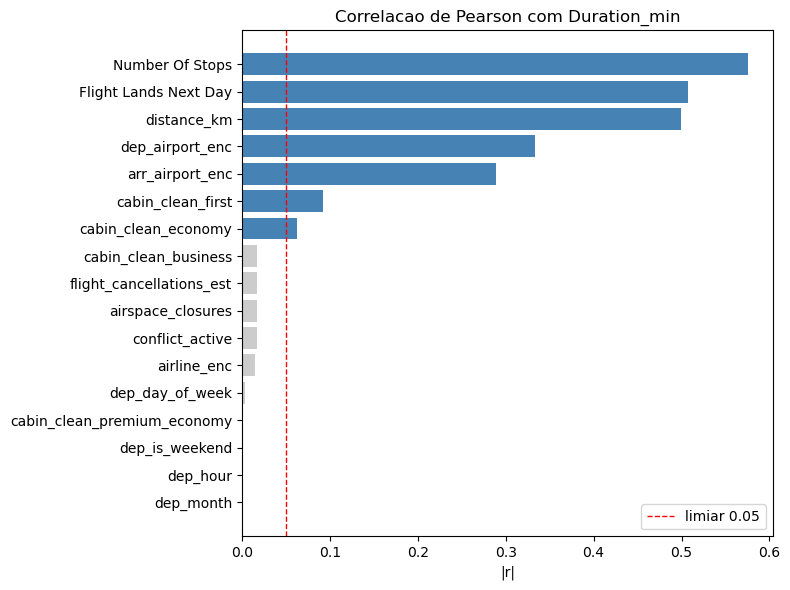

Features selecionadas pelo Pearson (duracao): 7
['Flight Lands Next Day', 'Number Of Stops', 'arr_airport_enc', 'cabin_clean_economy', 'cabin_clean_first', 'dep_airport_enc', 'distance_km']


In [45]:
# correlacao de Pearson - duracao
pearson_duracao = X_duracao.corrwith(y_duracao).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue" if v >= 0.05 else "#cccccc" for v in pearson_duracao.values]
ax.barh(pearson_duracao.index[::-1], pearson_duracao.values[::-1], color=colors[::-1])
ax.axvline(0.05, color="red", linestyle="--", linewidth=1, label="limiar 0.05")
ax.set_title("Correlacao de Pearson com Duration_min", fontsize=12)
ax.set_xlabel("|r|")
ax.legend()
plt.tight_layout()
plt.show()

pearson_duracao_selected = set(pearson_duracao[pearson_duracao >= 0.05].index)
print(f"Features selecionadas pelo Pearson (duracao): {len(pearson_duracao_selected)}")
print(sorted(pearson_duracao_selected))

#### 5.2. LASSO

O LASSO (Least Absolute Shrinkage and Selection Operator) é uma regressão linear com penalização L1. Ao contrário do Pearson, avalia todas as features em simultâneo e força a zero os coeficientes das features que não contribuem para o modelo. As features com coeficiente não-nulo são consideradas relevantes.

Os dados são normalizados antes de aplicar o LASSO, para que a penalização seja justa entre features em escalas diferentes.

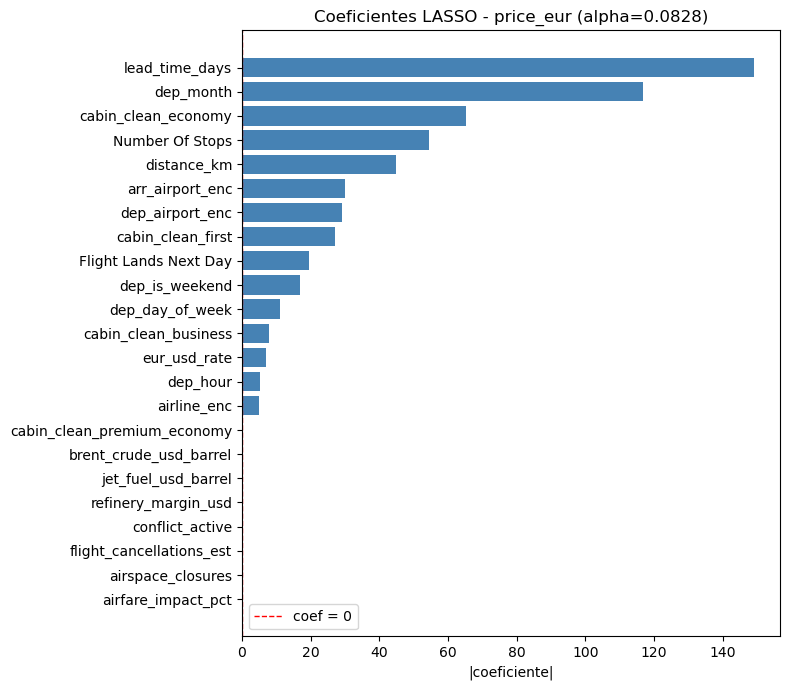

Features selecionadas pelo LASSO (custo): 15
['Flight Lands Next Day', 'Number Of Stops', 'airline_enc', 'arr_airport_enc', 'cabin_clean_business', 'cabin_clean_economy', 'cabin_clean_first', 'dep_airport_enc', 'dep_day_of_week', 'dep_hour', 'dep_is_weekend', 'dep_month', 'distance_km', 'eur_usd_rate', 'lead_time_days']


In [46]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# normalizar features (necessario para o LASSO ser justo entre escalas)
scaler = StandardScaler()

# custo
X_custo_scaled = scaler.fit_transform(X_custo)
lasso_custo = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso_custo.fit(X_custo_scaled, y_custo)

coef_custo = pd.Series(np.abs(lasso_custo.coef_), index=features_custo_all).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue" if v > 0 else "#cccccc" for v in coef_custo.values]
ax.barh(coef_custo.index[::-1], coef_custo.values[::-1], color=colors[::-1])
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="coef = 0")
ax.set_title(f"Coeficientes LASSO - price_eur (alpha={lasso_custo.alpha_:.4f})", fontsize=12)
ax.set_xlabel("|coeficiente|")
ax.legend()
plt.tight_layout()
plt.show()

lasso_custo_selected = set(coef_custo[coef_custo > 0].index)
print(f"Features selecionadas pelo LASSO (custo): {len(lasso_custo_selected)}")
print(sorted(lasso_custo_selected))

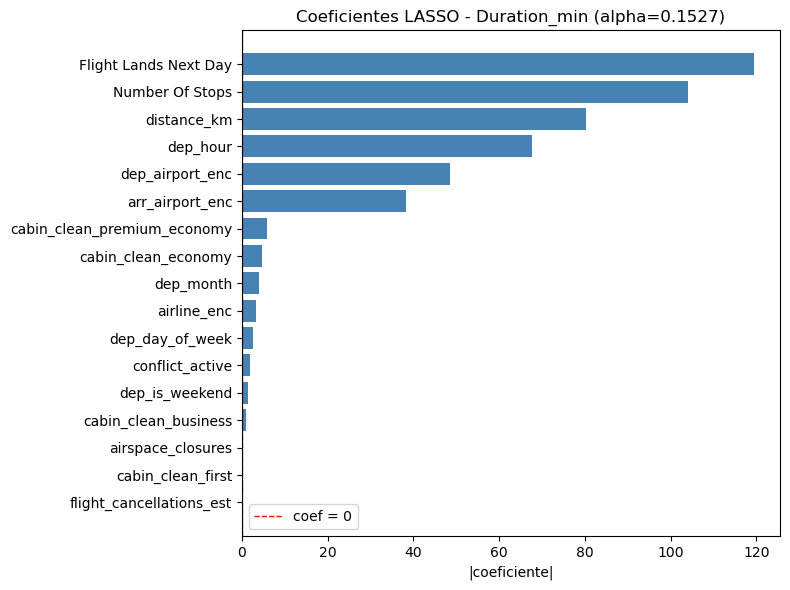

Features selecionadas pelo LASSO (duracao): 15
['Flight Lands Next Day', 'Number Of Stops', 'airline_enc', 'airspace_closures', 'arr_airport_enc', 'cabin_clean_business', 'cabin_clean_economy', 'cabin_clean_premium_economy', 'conflict_active', 'dep_airport_enc', 'dep_day_of_week', 'dep_hour', 'dep_is_weekend', 'dep_month', 'distance_km']


In [47]:
# duracao
X_duracao_scaled = scaler.fit_transform(X_duracao)
lasso_duracao = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso_duracao.fit(X_duracao_scaled, y_duracao)

coef_duracao = pd.Series(np.abs(lasso_duracao.coef_), index=features_duracao_all).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue" if v > 0 else "#cccccc" for v in coef_duracao.values]
ax.barh(coef_duracao.index[::-1], coef_duracao.values[::-1], color=colors[::-1])
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="coef = 0")
ax.set_title(f"Coeficientes LASSO - Duration_min (alpha={lasso_duracao.alpha_:.4f})", fontsize=12)
ax.set_xlabel("|coeficiente|")
ax.legend()
plt.tight_layout()
plt.show()

lasso_duracao_selected = set(coef_duracao[coef_duracao > 0].index)
print(f"Features selecionadas pelo LASSO (duracao): {len(lasso_duracao_selected)}")
print(sorted(lasso_duracao_selected))

#### 5.3. Feature importance - Random Forest

O Random Forest mede a importância de cada feature pela redução média do erro quadrático que ela proporciona nas divisões das árvores. Ao contrário do Pearson e do LASSO, captura relações não-lineares e interações entre features. É treinado um Random Forest rápido apenas para efeitos de seleção - não como modelo base final.

O critério de seleção é as **top N features por importância absoluta** (top 12 para custo, top 10 para duração).

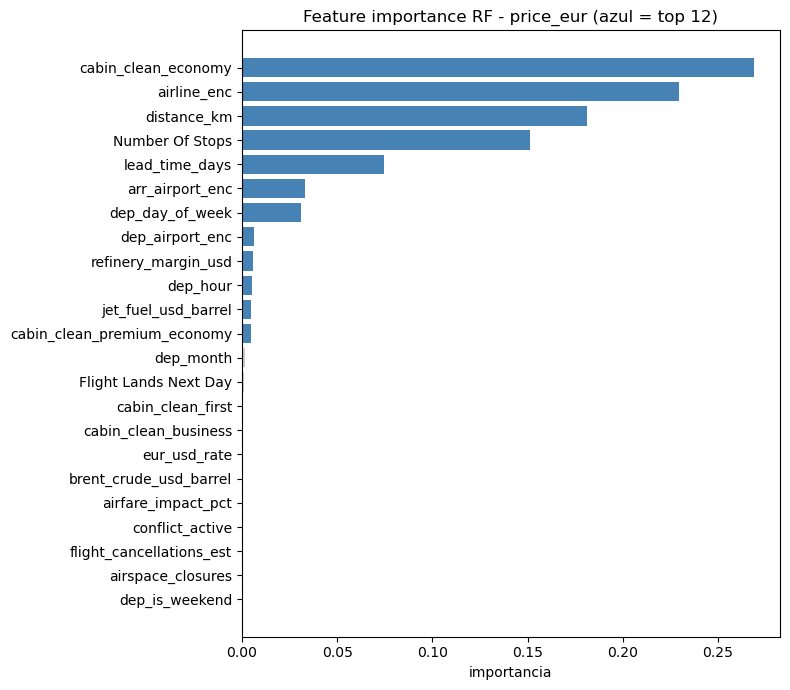

Features selecionadas pelo RF (custo): 12
['Number Of Stops', 'airline_enc', 'arr_airport_enc', 'cabin_clean_economy', 'cabin_clean_premium_economy', 'dep_airport_enc', 'dep_day_of_week', 'dep_hour', 'distance_km', 'jet_fuel_usd_barrel', 'lead_time_days', 'refinery_margin_usd']


In [48]:
from sklearn.ensemble import RandomForestRegressor

# custo - RF rapido para selecao (n_estimators reduzido)
rf_custo = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_custo.fit(X_custo, y_custo)

imp_custo = pd.Series(rf_custo.feature_importances_, index=features_custo_all).sort_values(ascending=False)

# criterio: top 12 features por importancia absoluta
# o criterio de importancia acumulada e demasiado restritivo quando uma feature domina
top_n_custo = 12
limiar_custo = imp_custo.head(top_n_custo).index.tolist()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue" if f in limiar_custo else "#cccccc" for f in imp_custo.index[::-1]]
ax.barh(imp_custo.index[::-1], imp_custo.values[::-1], color=colors)
ax.set_title(f"Feature importance RF - price_eur (azul = top {top_n_custo})", fontsize=12)
ax.set_xlabel("importancia")
plt.tight_layout()
plt.show()

rf_custo_selected = set(limiar_custo)
print(f"Features selecionadas pelo RF (custo): {len(rf_custo_selected)}")
print(sorted(rf_custo_selected))

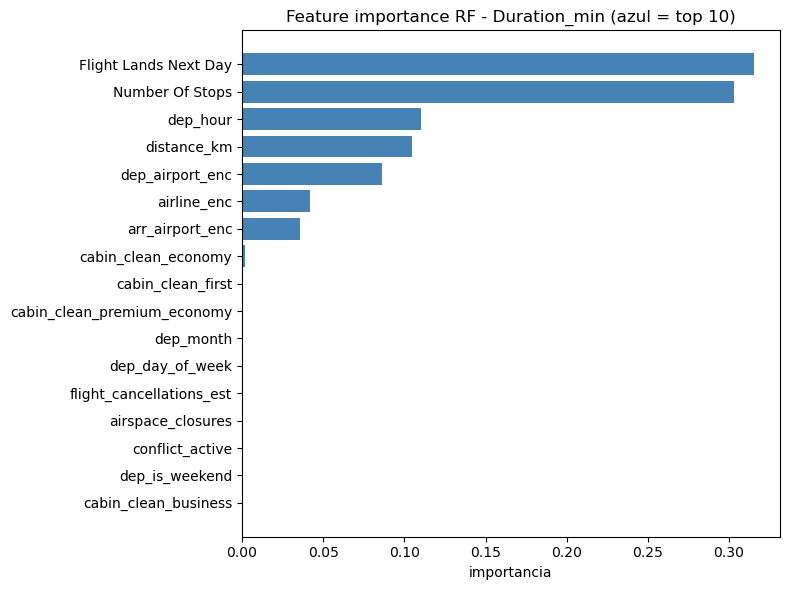

Features selecionadas pelo RF (duracao): 10
['Flight Lands Next Day', 'Number Of Stops', 'airline_enc', 'arr_airport_enc', 'cabin_clean_economy', 'cabin_clean_first', 'cabin_clean_premium_economy', 'dep_airport_enc', 'dep_hour', 'distance_km']


In [49]:
# duracao - RF rapido para selecao
rf_duracao = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_duracao.fit(X_duracao, y_duracao)

imp_duracao = pd.Series(rf_duracao.feature_importances_, index=features_duracao_all).sort_values(ascending=False)

# criterio: top 10 features por importancia absoluta
top_n_duracao = 10
limiar_duracao = imp_duracao.head(top_n_duracao).index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue" if f in limiar_duracao else "#cccccc" for f in imp_duracao.index[::-1]]
ax.barh(imp_duracao.index[::-1], imp_duracao.values[::-1], color=colors)
ax.set_title(f"Feature importance RF - Duration_min (azul = top {top_n_duracao})", fontsize=12)
ax.set_xlabel("importancia")
plt.tight_layout()
plt.show()

rf_duracao_selected = set(limiar_duracao)
print(f"Features selecionadas pelo RF (duracao): {len(rf_duracao_selected)}")
print(sorted(rf_duracao_selected))

#### 5.4. Decisão final - cruzamento dos 3 métodos

Uma feature é mantida se for selecionada por **pelo menos 2 dos 3 métodos** (Pearson, LASSO, Random Forest). Este critério garante robustez: não depende de um único método e elimina features que apenas um método considera relevantes por acaso.

In [50]:
# custo: votos de cada metodo
todos_custo = sorted(features_custo_all)
summary_custo = pd.DataFrame({
    "feature": todos_custo,
    "pearson": [f in pearson_custo_selected for f in todos_custo],
    "lasso":   [f in lasso_custo_selected   for f in todos_custo],
    "rf":      [f in rf_custo_selected       for f in todos_custo],
})
summary_custo["votos"] = summary_custo[["pearson","lasso","rf"]].sum(axis=1)
summary_custo = summary_custo.sort_values("votos", ascending=False)

features_custo_selected = summary_custo[summary_custo["votos"] >= 2]["feature"].tolist()

print("Custo:")
display(summary_custo)
print(f"\nFeatures selecionadas (votos >= 2): {len(features_custo_selected)}")
print(features_custo_selected)

Custo:


,feature,pearson,lasso,rf,votos
1,Number Of Stops,True,True,True,3
5,arr_airport_enc,True,True,True,3
21,lead_time_days,True,True,True,3
12,dep_airport_enc,True,True,True,3
13,dep_day_of_week,True,True,True,3
14,dep_hour,True,True,True,3
8,cabin_clean_economy,True,True,True,3
17,distance_km,True,True,True,3
22,refinery_margin_usd,True,False,True,2
16,dep_month,True,True,False,2



Features selecionadas (votos >= 2): 16
['Number Of Stops', 'arr_airport_enc', 'lead_time_days', 'dep_airport_enc', 'dep_day_of_week', 'dep_hour', 'cabin_clean_economy', 'distance_km', 'refinery_margin_usd', 'dep_month', 'dep_is_weekend', 'airline_enc', 'cabin_clean_business', 'cabin_clean_premium_economy', 'cabin_clean_first', 'jet_fuel_usd_barrel']


In [51]:
# duracao: votos de cada metodo
todos_duracao = sorted(features_duracao_all)
summary_duracao = pd.DataFrame({
    "feature": todos_duracao,
    "pearson": [f in pearson_duracao_selected for f in todos_duracao],
    "lasso":   [f in lasso_duracao_selected   for f in todos_duracao],
    "rf":      [f in rf_duracao_selected       for f in todos_duracao],
})
summary_duracao["votos"] = summary_duracao[["pearson","lasso","rf"]].sum(axis=1)
summary_duracao = summary_duracao.sort_values("votos", ascending=False)

features_duracao_selected = summary_duracao[summary_duracao["votos"] >= 2]["feature"].tolist()

print("Duração:")
display(summary_duracao)
print(f"\nFeatures selecionadas (votos >= 2): {len(features_duracao_selected)}")
print(features_duracao_selected)

Duração:


,feature,pearson,lasso,rf,votos
0,Flight Lands Next Day,True,True,True,3
1,Number Of Stops,True,True,True,3
4,arr_airport_enc,True,True,True,3
6,cabin_clean_economy,True,True,True,3
10,dep_airport_enc,True,True,True,3
15,distance_km,True,True,True,3
7,cabin_clean_first,True,False,True,2
8,cabin_clean_premium_economy,False,True,True,2
2,airline_enc,False,True,True,2
12,dep_hour,False,True,True,2



Features selecionadas (votos >= 2): 10
['Flight Lands Next Day', 'Number Of Stops', 'arr_airport_enc', 'cabin_clean_economy', 'dep_airport_enc', 'distance_km', 'cabin_clean_first', 'cabin_clean_premium_economy', 'airline_enc', 'dep_hour']


#### 5.5. Dois cenários de modelação

A seleção de features revelou que as variáveis contextuais externas (combustível, conflito, câmbio) obtiveram 0 ou 1 voto na maioria dos casos. Isto não significa que sejam irrelevantes para o sistema - significa que o dataset utilizado, com apenas 6 meses de cobertura temporal, não tem variação suficiente para que os métodos de seleção detetem o seu efeito.

Para lidar com esta limitação, os modelos serão treinados e avaliados em **dois cenários paralelos**:

- **Cenário A** (`features_selected`): apenas as features com pelo menos 2 votos na seleção. Representa o que os dados atuais conseguem validar estatisticamente.

- **Cenário B** (`features_all`): todas as features previstas no sistema, incluindo as externas. Representa o sistema final desenhado para dados de vários anos.

A comparação das métricas entre os dois cenários permitirá perceber o impacto das variáveis externas neste contexto de dados limitado, e justificar a sua inclusão no sistema final.

In [52]:
print("-> Cenario A - features selecionadas (votos >= 2):")
print(f"\nCUSTO ({len(features_custo_selected)} features):")
for i, f in enumerate(features_custo_selected, 1):
    print(f"  {i:2}. {f}")

print(f"\nDURACAO ({len(features_duracao_selected)} features):")
for i, f in enumerate(features_duracao_selected, 1):
    print(f"  {i:2}. {f}")

print("\n-> Cenario B - todas as features (sem filtragem):")
print(f"\nCUSTO ({len(features_custo_all)} features):")
for i, f in enumerate(features_custo_all, 1):
    print(f"  {i:2}. {f}")

print(f"\nDURACAO ({len(features_duracao_all)} features):")
for i, f in enumerate(features_duracao_all, 1):
    print(f"  {i:2}. {f}")

-> Cenario A - features selecionadas (votos >= 2):

CUSTO (16 features):
   1. Number Of Stops
   2. arr_airport_enc
   3. lead_time_days
   4. dep_airport_enc
   5. dep_day_of_week
   6. dep_hour
   7. cabin_clean_economy
   8. distance_km
   9. refinery_margin_usd
  10. dep_month
  11. dep_is_weekend
  12. airline_enc
  13. cabin_clean_business
  14. cabin_clean_premium_economy
  15. cabin_clean_first
  16. jet_fuel_usd_barrel

DURACAO (10 features):
   1. Flight Lands Next Day
   2. Number Of Stops
   3. arr_airport_enc
   4. cabin_clean_economy
   5. dep_airport_enc
   6. distance_km
   7. cabin_clean_first
   8. cabin_clean_premium_economy
   9. airline_enc
  10. dep_hour

-> Cenario B - todas as features (sem filtragem):

CUSTO (23 features):
   1. distance_km
   2. Number Of Stops
   3. lead_time_days
   4. airline_enc
   5. Flight Lands Next Day
   6. dep_airport_enc
   7. arr_airport_enc
   8. cabin_clean_business
   9. cabin_clean_economy
  10. cabin_clean_first
  11. cabin_c

### 6. Modelação - Stacking de dois níveis

Esta secção implementa a arquitectura de stacking definida para o sistema de previsão. O stacking é treinado separadamente para cada target (custo e duração) e para cada cenário (A e B).

A pipeline para cada combinação target x cenário é:

1. **Nível 0** - três modelos base treinados com validação walk-forward de 5 folds; as previsões out-of-fold são guardadas para alimentar o meta-modelo.
2. **Nível 1** - meta-modelo Ridge treinado com as previsões out-of-fold dos modelos base mais as features originais selecionadas.

A validação walk-forward garante que o modelo treina sempre com dados do passado e prevê dados do futuro, evitando data leakage temporal.

#### 6.1. Função de validação walk-forward

O walk-forward divide os dados em 5 folds temporais ordenados. Em cada fold, o modelo treina com todos os dados anteriores e prevê o bloco seguinte (a janela de treino cresce progressivamente). As previsões de cada fold são guardadas (out-of-fold) e usadas como input do meta-modelo Ridge no nível 1.

In [53]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

def walk_forward_oof(models, X, y, n_splits=5, scale=False):
    """
    Validacao walk-forward com n_splits folds temporais.
    Retorna matriz de previsoes out-of-fold (shape: n_samples x n_models).

    Se scale=True, aplica StandardScaler dentro de cada fold:
    - o scaler e treinado apenas com os dados de treino do fold (fit)
    - aplicado aos dados de teste com o mesmo scaler (transform)
    Desta forma nao ha data leakage - o modelo de teste nunca ve
    informacao dos dados de treino atraves da normalizacao.
    """
    n = len(X)
    fold_size = n // n_splits
    oof_preds = np.full((n, len(models)), np.nan)

    for fold in range(n_splits):
        train_end  = (fold + 1) * fold_size
        test_start = train_end
        test_end   = test_start + fold_size if fold < n_splits - 1 else n

        if train_end == 0 or test_start >= n:
            continue

        X_tr = X.iloc[:train_end].values
        X_te = X.iloc[test_start:test_end].values
        y_tr = y.iloc[:train_end].values

        if scale:
            # scaler treinado so com dados de treino deste fold - sem data leakage
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)  # normaliza dados de treino
            X_te = scaler.transform(X_te)      # normaliza dados de teste com o que ja foi aprendido

        idx_test = list(range(test_start, test_end))

        for j, model in enumerate(models):
            m = model.__class__(**model.get_params())
            m.fit(X_tr, y_tr)
            oof_preds[idx_test, j] = m.predict(X_te)

    return oof_preds

print("Funcao walk_forward_oof definida com scaler correto dentro de cada fold.")

Funcao walk_forward_oof definida com scaler correto dentro de cada fold.


#### 6.2. Função de avaliação do stacking completo

Esta função contém o pipeline completo de stacking para um dado target e o conjunto de features: treina os modelos base com walk-forward, obtém as previsões out-of-fold, treina o meta-modelo Ridge no nível 1, e calcula as métricas de avaliação.

In [54]:
def run_stacking(df_input, features, target, models_base, label="", scale=False):
    """
    Pipeline completo de stacking de 2 niveis.
    Nivel 0: modelos base com walk-forward OOF.
             Se scale=True, o StandardScaler e aplicado dentro de cada fold
             (treinado so com dados de treino).
    Nivel 1: Ridge treinado com OOF + features originais.
    """
    df_sorted = df_input.sort_values("Departure Date").reset_index(drop=True)
    X = df_sorted[features]
    y = df_sorted[target]

    print(f"\n{label}")
    print(f"  registos: {len(X):,} | features: {len(features)} | target: {target}")
    if scale:
        print("  normalizacao: StandardScaler aplicado dentro de cada fold")

    # nivel 0 - OOF com walk-forward
    oof_preds = walk_forward_oof(models_base, X, y, n_splits=5, scale=scale)

    # usar apenas linhas com previsoes
    mask = ~np.isnan(oof_preds[:, 0])
    oof_preds_valid = oof_preds[mask]
    y_valid         = y[mask].values
    X_valid         = X[mask]

    # nivel 1 - Ridge: OOF + features originais
    X_meta = np.hstack([oof_preds_valid, X_valid.values])
    ridge  = Ridge(alpha=1.0)
    ridge.fit(X_meta, y_valid)
    y_pred = ridge.predict(X_meta)

    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae  = mean_absolute_error(y_valid, y_pred)
    r2   = r2_score(y_valid, y_pred)

    print(f"  RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")

    return {"label": label, "rmse": rmse, "mae": mae, "r2": r2,
            "y_valid": y_valid, "y_pred": y_pred,
            "oof_preds": oof_preds_valid, "ridge": ridge}

print("Funcao run_stacking definida.")

Funcao run_stacking definida.


#### 6.3. Modelos base - Nível 0

Modelos base:

- **Custo**: Regressão Linear, Random Forest, XGBoost
- **Duração**: Random Forest, LinearSVR, XGBoost

**Nota sobre o SVR:** a arquitetura original previa SVR com kernel RBF para a duração. No entanto, o SVR com kernel RBF tem complexidade computacional O(n²) a O(n³) no treino - com 317k registos e 5 folds walk-forward, o tempo de treino é de várias horas, tornando-o demasiado complexo para este teste inicial.

A alternativa é o **LinearSVR**, que usa um kernel linear com complexidade O(n), treinando mais rápido. É uma escolha adotada para datasets de grande dimensão, e justificável como aproximação ao SVR completo quando o volume de dados inviabiliza o kernel RBF.

O LinearSVR requer normalização das features - aplicada dentro de cada fold do walk-forward sem data leakage, conforme descrito na secção 6.1.

In [55]:
# modelos base para custo
models_custo = [
    LinearRegression(),
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                 random_state=42, verbosity=0),
]

# modelos base para duracao
# LinearSVR em vez de SVR (kernel RBF)
models_duracao = [
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    LinearSVR(C=1.0, max_iter=2000, random_state=42),
    XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                 random_state=42, verbosity=0),
]

print("Modelos base definidos.")
print(f"  Custo:   {[m.__class__.__name__ for m in models_custo]}")
print(f"  Duracao: {[m.__class__.__name__ for m in models_duracao]}")

Modelos base definidos.
  Custo:   ['LinearRegression', 'RandomForestRegressor', 'XGBRegressor']
  Duracao: ['RandomForestRegressor', 'LinearSVR', 'XGBRegressor']


#### 6.4. Treino e avaliação - Cenário A (features selecionadas)

O Cenário A usa apenas as features que obtiveram pelo menos 2 votos na seleção. Representa o que os dados atuais conseguem validar estatisticamente - sem as variáveis externas que têm pouca variação nos 6 meses disponíveis.

In [56]:
# custo: sem normalizacao (LinearRegression, RF e XGBoost nao sao sensiveis a escala)
# duracao: scale=True porque inclui LinearSVR - o scaler e aplicado dentro de cada
#          fold do walk-forward, treinado so com dados de treino, sem data leakage
res_custo_A   = run_stacking(df_model, features_custo_selected,   "price_eur",
                             models_custo,   "Cenario A - Custo",   scale=False)
res_duracao_A = run_stacking(df_model, features_duracao_selected, "Duration_min",
                             models_duracao, "Cenario A - Duracao", scale=True)


Cenario A - Custo
  registos: 317,260 | features: 16 | target: price_eur
  RMSE: 106.91 | MAE: 74.70 | R2: 0.7106

Cenario A - Duracao
  registos: 317,260 | features: 10 | target: Duration_min
  normalizacao: StandardScaler aplicado dentro de cada fold
  RMSE: 97.68 | MAE: 68.33 | R2: 0.8660


#### 6.5. Treino e avaliação - Cenário B (todas as features)

O Cenário B usa todas as features previstas no sistema, incluindo as variáveis externas (combustível, conflito, câmbio). Representa o sistema final desenhado para dados de vários anos. Com apenas 6 meses de dados, espera-se que as métricas sejam semelhantes ou ligeiramente inferiores ao Cenário A, dado que as variáveis externas têm pouca variação e podem introduzir ruído.

In [57]:
res_custo_B   = run_stacking(df_model, features_custo_all,   "price_eur",
                             models_custo,   "Cenario B - Custo",   scale=False)
res_duracao_B = run_stacking(df_model, features_duracao_all, "Duration_min",
                             models_duracao, "Cenario B - Duracao", scale=True)


Cenario B - Custo
  registos: 317,260 | features: 23 | target: price_eur
  RMSE: 106.71 | MAE: 74.60 | R2: 0.7116

Cenario B - Duracao
  registos: 317,260 | features: 17 | target: Duration_min
  normalizacao: StandardScaler aplicado dentro de cada fold
  RMSE: 98.01 | MAE: 68.68 | R2: 0.8651


#### 6.6. Comparação de resultados - Cenário A vs Cenário B

In [58]:
resultados = pd.DataFrame([
    {"cenario": "A", "target": "custo",   "features": len(features_custo_selected),
     "RMSE": res_custo_A["rmse"],   "MAE": res_custo_A["mae"],   "R2": res_custo_A["r2"]},
    {"cenario": "A", "target": "duracao", "features": len(features_duracao_selected),
     "RMSE": res_duracao_A["rmse"], "MAE": res_duracao_A["mae"], "R2": res_duracao_A["r2"]},
    {"cenario": "B", "target": "custo",   "features": len(features_custo_all),
     "RMSE": res_custo_B["rmse"],   "MAE": res_custo_B["mae"],   "R2": res_custo_B["r2"]},
    {"cenario": "B", "target": "duracao", "features": len(features_duracao_all),
     "RMSE": res_duracao_B["rmse"], "MAE": res_duracao_B["mae"], "R2": res_duracao_B["r2"]},
])

print("Comparacao Cenario A vs Cenario B:")
display(resultados.round(4))

Comparacao Cenario A vs Cenario B:


,cenario,target,features,RMSE,MAE,R2
0,A,custo,16,106.9058,74.7042,0.7106
1,A,duracao,10,97.6781,68.3264,0.8660
2,B,custo,23,106.7139,74.6002,0.7116
3,B,duracao,17,98.0050,68.6803,0.8651


##### 6.6.1. Erro relativo - tornar os RMSE comparáveis

O RMSE está nas unidades do target: euros para o custo e minutos para a duração. Comparar 106.91 com 97.68 diretamente não tem significado - são escalas completamente diferentes. Para tornar os erros comparáveis entre targets, calcula-se o **erro relativo**: RMSE dividido pela média do target, expresso em percentagem. Desta forma percebe-se o quão grande é o erro em relação aos valores que o modelo está a prever.

In [59]:
# medias dos targets (calculadas sobre o dataset de modelacao)
media_custo   = df_model["price_eur"].mean()
media_duracao = df_model["Duration_min"].mean()

# erro relativo para cada cenario e target
resultados["media_target"] = resultados["target"].map({
    "custo":   media_custo,
    "duracao": media_duracao
})
resultados["RMSE_rel_pct"] = (resultados["RMSE"] / resultados["media_target"] * 100).round(2)
resultados["MAE_rel_pct"]  = (resultados["MAE"]  / resultados["media_target"] * 100).round(2)

print(f"Media do preco (price_eur):    {media_custo:.2f} EUR")
print(f"Media da duracao (Duration_min): {media_duracao:.2f} min")
print()
display(resultados[["cenario","target","features","RMSE","RMSE_rel_pct","MAE","MAE_rel_pct","R2"]].round(4))

Media do preco (price_eur):    332.17 EUR
Media da duracao (Duration_min): 565.68 min



,cenario,target,features,RMSE,RMSE_rel_pct,MAE,MAE_rel_pct,R2
0,A,custo,16,106.9058,32.18,74.7042,22.49,0.7106
1,A,duracao,10,97.6781,17.27,68.3264,12.08,0.8660
2,B,custo,23,106.7139,32.13,74.6002,22.46,0.7116
3,B,duracao,17,98.0050,17.33,68.6803,12.14,0.8651


Os modelos foram avaliados com duas métricas principais: RMSE (Root Mean Squared Error) e R².


O **RMSE** mede o erro médio nas unidades do target - euros para o custo e minutos para a duração. Quanto ao RMSE relativo, em percentagem:

- **Custo**: RMSE de 106€ com média de aproximadamente 330€ -> **erro relativo de aproximadamente 32.2%**
- **Duração**: RMSE de 97.68 min com média de aproximadamente 566 min -> **erro relativo de aproximadamente 17.3%**

O **R²** é adimensional e indica a percentagem da variação do target que o modelo consegue explicar:

- **Custo**: R² = 0.7110 -> o modelo **explica 71.1% da variação do preço**. É um resultado explicável pelos apenas 6 meses de dados domésticos nos EUA deste teste inicial, sem outras features relevantes neste contexto e com variáveis externas com pouca variação temporal. Há margem clara para melhorar com dados mais ricos e de maior cobertura temporal.
- **Duração**: R² = 0.8660 -> o modelo **explica 86.6% da variação da duração**. É aceitável para um teste inicial sem as features mais relevantes para a duração: clima, atraso histórico da rota e risco de greve.

**Cenário A vs Cenário B**

Para o custo, o Cenário B supera ligeiramente o A (R²: 0.7116 vs 0.7106). As features externas (`jet_fuel_usd_barrel`, `refinery_margin_usd`) captam um pequeno efeito positivo mesmo com apenas 6 meses de dados, o que é consistente com o papel que estas variáveis terão no sistema final.

Para a duração, o Cenário B é marginalmente pior que o A (R² 0.8651 vs 0.8660) - as features externas de conflito acrescentam mais ruído do que sinal para a duração com a cobertura temporal disponível.

Em ambos os casos a diferença entre cenários é pequena, confirmando a hipótese
formulada: **com apenas 6 meses de dados, as variáveis externas não têm variação suficiente para ter impacto significativo**. No sistema final, com dados de vários anos e eventos como crises energéticas ou conflitos geopolíticos, espera-se que o Cenário B supere claramente o A.

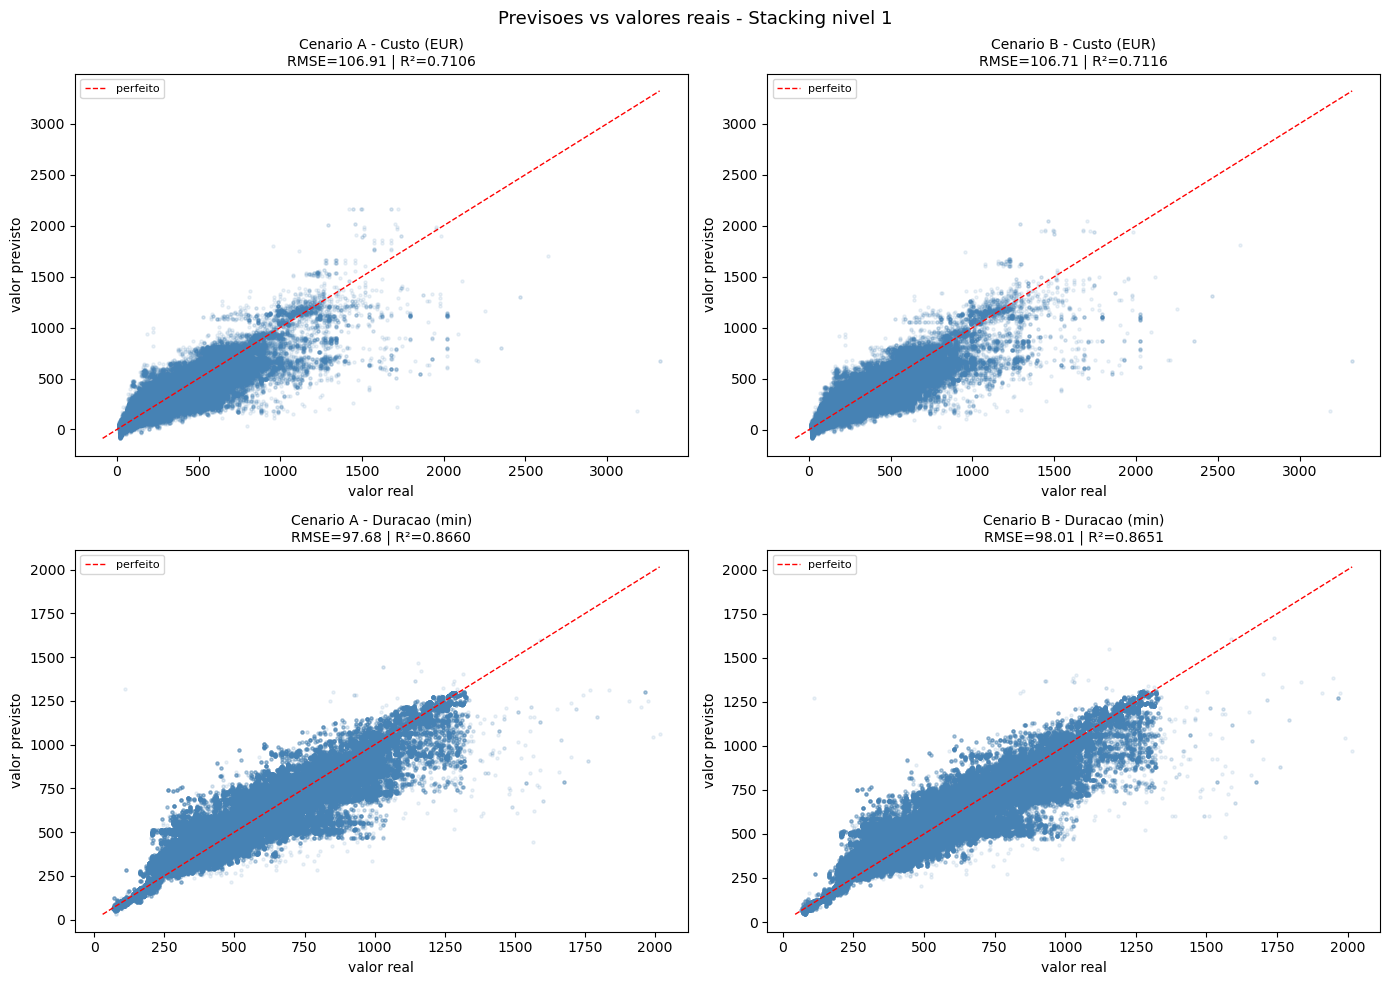

In [60]:
# visualizacao: previsoes vs valores reais para cada combinacao
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (axes[0,0], res_custo_A,   "Cenario A - Custo (EUR)",      "price_eur"),
    (axes[0,1], res_custo_B,   "Cenario B - Custo (EUR)",      "price_eur"),
    (axes[1,0], res_duracao_A, "Cenario A - Duracao (min)",    "Duration_min"),
    (axes[1,1], res_duracao_B, "Cenario B - Duracao (min)",    "Duration_min"),
]

for ax, res, title, _ in configs:
    ax.scatter(res["y_valid"], res["y_pred"], alpha=0.1, s=5, color="steelblue")
    lims = [min(res["y_valid"].min(), res["y_pred"].min()),
            max(res["y_valid"].max(), res["y_pred"].max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="perfeito")
    ax.set_xlabel("valor real")
    ax.set_ylabel("valor previsto")
    ax.set_title(f"{title}\nRMSE={res['rmse']:.2f} | R²={res['r2']:.4f}", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Previsoes vs valores reais - Stacking nivel 1", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretação dos Gráficos**:

- **Custo (linha de cima)** - os pontos seguem a tendência da linha vermelha mas com dispersão considerável, especialmente entre os 500€ e os 1500€. O modelo subestima frequentemente os voos mais caros - os pontos ficam abaixo da linha vermelha acima dos 1000€ - e há outliers visíveis que o modelo não consegue capturar. Isto reflete o R² de 0.71: o modelo capta a tendência geral do preço mas não explica bem a variação individual de cada voo, o que é expectável sem grande variedade de features externas.

- **Duração (linha de baixo)** - o padrão é mais coeso do que no custo, com os pontos mais próximos da linha vermelha na zona central (250 a 1000 minutos). O modelo tende a subestimar durações longas - acima dos 1000 minutos os pontos ficam consistentemente abaixo da linha, o que significa que para voos com muitas escalas ou rotas operacionalmente imprevisíveis, o modelo prevê menos do que a realidade. Faz sentido porque o dataset não tem features de atraso histórico, clima ou outras features externas que são, normalmente, os principais fatores que fazem os voos demorar mais do que o esperado.

### 7. Interpretabilidade - SHAP

A interpretabilidade é uma componente essencial do sistema de previsão. O modelo não deve apenas prever - deve também justificar as suas previsões, permitindo perceber porque o custo subiu, porque a duração foi penalizada ou porque uma rota passou a ser mais cara num determinado mês.

Neste teste inicial é usada a técnica SHAP (SHapley Additive exPlanations), que calcula a contribuição de cada feature para cada previsão individual. É aplicada ao meta-modelo Ridge do nível 1, usando os valores out-of-fold já calculados na secção 6.

#### 7.1. SHAP - Custo

O `summary_plot` mostra todas as features ordenadas por importância global (eixo Y) e o valor SHAP de cada observação (eixo X). A cor representa o valor da feature: vermelho = valor alto, azul = valor baixo. Um SHAP positivo significa que a feature aumentou o preço previsto; negativo que o reduziu.

In [66]:
print("oof_preds shape:", res_custo_A["oof_preds"].shape)
print("y_valid shape:", res_custo_A["y_valid"].shape)
print("y_pred shape:", res_custo_A["y_pred"].shape)
print("df_model shape:", df_model.shape)

oof_preds shape: (253808, 3)
y_valid shape: (253808,)
y_pred shape: (253808,)
df_model shape: (317260, 45)


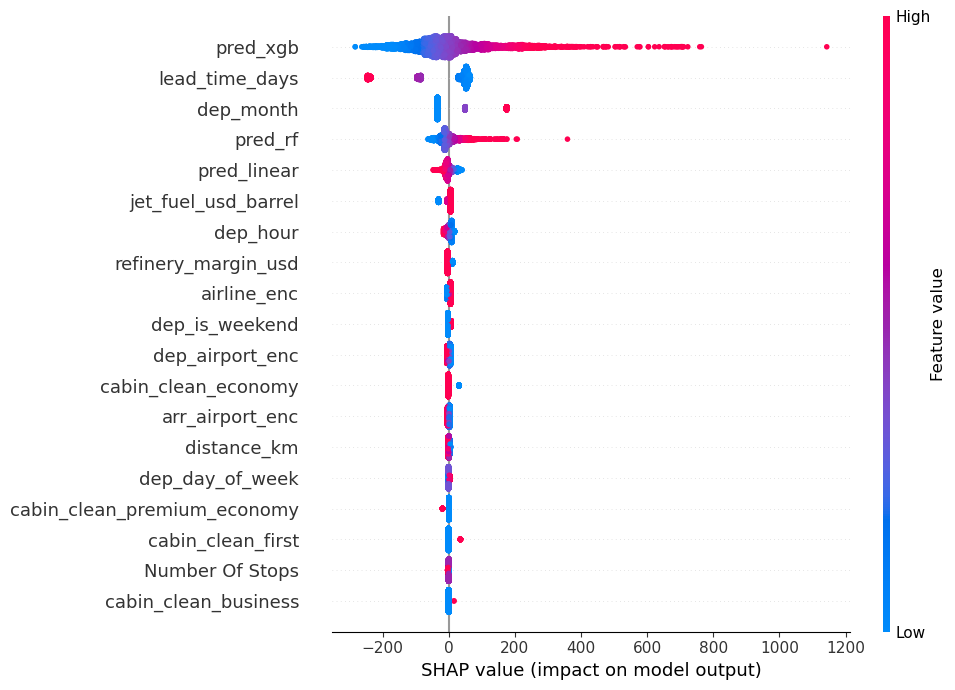

In [98]:
import numpy as np
import shap

df_sorted = df_model.sort_values("Departure Date").reset_index(drop=True)
n_valid = res_custo_A["oof_preds"].shape[0]
X_valid_custo = df_sorted[features_custo_selected].iloc[-n_valid:].reset_index(drop=True)

# forçar tudo para float64 - necessario para o SHAP
X_meta_custo = np.hstack([
    res_custo_A["oof_preds"].astype(np.float64),
    X_valid_custo.values.astype(np.float64)
])
col_names_custo = ["pred_linear", "pred_rf", "pred_xgb"] + features_custo_selected

explainer_custo = shap.LinearExplainer(res_custo_A["ridge"], X_meta_custo)
shap_values_custo = explainer_custo.shap_values(X_meta_custo)

sample_idx = np.random.choice(len(X_meta_custo), size=min(5000, len(X_meta_custo)), replace=False)
shap.summary_plot(
    shap_values_custo[sample_idx],
    X_meta_custo[sample_idx],
    feature_names=col_names_custo,
    show=True,
    plot_size=(10, 7)
)

As 3 primeiras features são as previsões dos modelos base (pred_xgb, pred_rf, pred_linear) - é esperado que dominem porque o Ridge do nível 1 está essencialmente a combinar estes 3 modelos. 

O `pred_xgb` é claramente o mais influente: valores altos (vermelho) puxam o preço para cima com SHAP até +1200€, e valores baixos (azul) puxam para baixo até -300€. O `pred_rf` tem um papel secundário mas ainda relevante. O `pred_linear` contribui pouco - faz sentido, a regressão linear é o modelo mais fraco dos três para este problema.

Das features originais, as mais relevantes são `lead_time_days` e `dep_month` - voos comprados com muita antecedência (azul) têm SHAP negativo (mais baratos), e voos em certos meses têm SHAP positivo (mais caros). O `jet_fuel_usd_barrel` e `refinery_margin_usd` aparecem mas com impacto muito pequeno, o que é consistente com o que já analisamos - pouca variação temporal.

#### 7.2. SHAP - Duração

O mesmo processo aplicado ao modelo de duração. As features mais relevantes para a duração devem ser as estruturais da viagem - escalas, distância, hora de partida - e não variáveis externas, o que é consistente com os resultados da seleção de features.

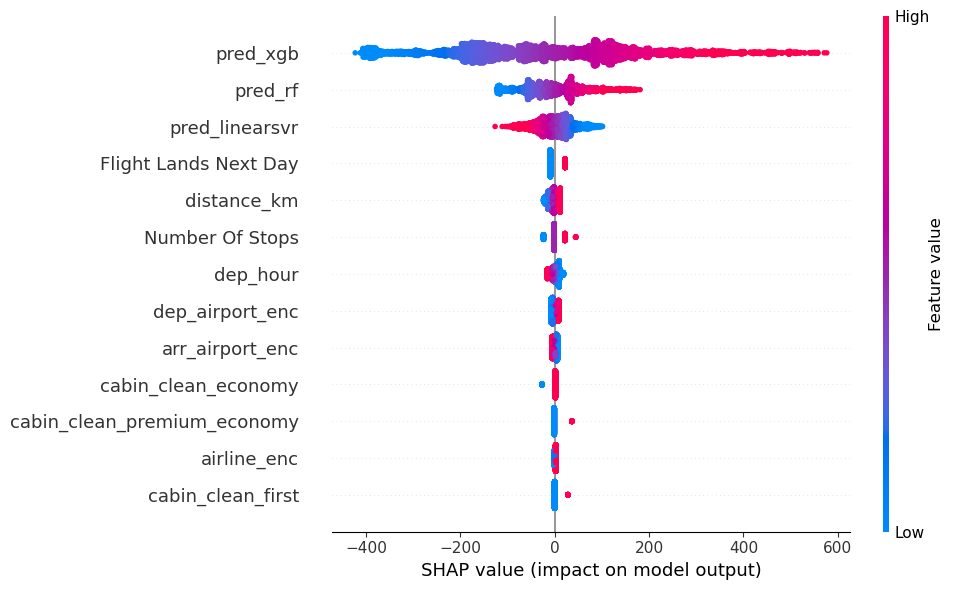

In [80]:
df_sorted_dur = df_model.sort_values("Departure Date").reset_index(drop=True)
n_valid_dur = res_duracao_A["oof_preds"].shape[0]
X_valid_dur = df_sorted_dur[features_duracao_selected].iloc[-n_valid_dur:].reset_index(drop=True)

X_meta_dur = np.hstack([
    res_duracao_A["oof_preds"].astype(np.float64),
    X_valid_dur.values.astype(np.float64)
])
col_names_dur = ["pred_rf", "pred_linearsvr", "pred_xgb"] + features_duracao_selected

explainer_dur = shap.LinearExplainer(res_duracao_A["ridge"], X_meta_dur)
shap_values_dur = explainer_dur.shap_values(X_meta_dur)

sample_idx_dur = np.random.choice(len(X_meta_dur), size=min(5000, len(X_meta_dur)), replace=False)
shap.summary_plot(
    shap_values_dur[sample_idx_dur],
    X_meta_dur[sample_idx_dur],
    feature_names=col_names_dur,
    show=True,
    plot_size=(10, 6)
)

O mesmo padrão: `pred_xgb` e `pred_rf` dominam, com o `pred_linearsvr` a ter um papel menor. Das features originais, `Flight Lands Next Day` e `distance_km` são as mais relevantes - voos que aterram no dia seguinte (vermelho) têm SHAP claramente positivo (mais longos), e rotas mais longas também aumentam a duração prevista. `Number Of Stops` e `dep_hour` completam com impacto moderado.

### 8. Camada de cenários

A camada de cenários simula futuros alternativos sem retreinar o modelo. O que muda são as features contextuais de entrada (preço do combustível, atividade de conflito, câmbio) e o modelo produz previsões diferentes para cada cenário.

Neste teste são simulados três cenários para um conjunto de rotas representativas:

- **Otimista** - combustível barato, sem conflitos
- **Balanceado** - valores atuais (médias do dataset)
- **Pessimista** - combustível caro, conflito ativo

Como o modelo foi treinado com o Cenário B (todas as features), é esse que se usa aqui para que as variáveis externas tenham efeito nas previsões.

#### 8.1. Previsões de custo por cenário

In [99]:
import pandas as pd

# valores base (medias do dataset)
base_oil = df_model["jet_fuel_usd_barrel"].mean()
base_brent = df_model["brent_crude_usd_barrel"].mean()
base_margin = df_model["refinery_margin_usd"].mean()
base_fx = df_model["eur_usd_rate"].mean()
base_conflict = df_model["conflict_active"].mean()
base_cancel = df_model["flight_cancellations_est"].mean()
base_closure = df_model["airspace_closures"].mean()
base_impact = df_model["airfare_impact_pct"].mean()

cenarios = {
    "Otimista": {
        "jet_fuel_usd_barrel":      base_oil    * 0.80,  # combustivel -20%
        "brent_crude_usd_barrel":   base_brent  * 0.80,
        "refinery_margin_usd":      base_margin * 0.80,
        "eur_usd_rate":             base_fx,
        "conflict_active":          0,
        "flight_cancellations_est": 0,
        "airspace_closures":        0,
        "airfare_impact_pct":       0,
    },
    "Balanceado": {
        "jet_fuel_usd_barrel":      base_oil,
        "brent_crude_usd_barrel":   base_brent,
        "refinery_margin_usd":      base_margin,
        "eur_usd_rate":             base_fx,
        "conflict_active":          base_conflict,
        "flight_cancellations_est": base_cancel,
        "airspace_closures":        base_closure,
        "airfare_impact_pct":       base_impact,
    },
    "Pessimista": {
        "jet_fuel_usd_barrel":      base_oil    * 1.30,  # combustivel +30%
        "brent_crude_usd_barrel":   base_brent  * 1.30,
        "refinery_margin_usd":      base_margin * 1.20,
        "eur_usd_rate":             base_fx,
        "conflict_active":          1,
        "flight_cancellations_est": df_model["flight_cancellations_est"].max(),
        "airspace_closures":        df_model["airspace_closures"].max(),
        "airfare_impact_pct":       df_model["airfare_impact_pct"].max(),
    },
}

print("Cenarios definidos (combustivel e conflito variam; cambio fixo):")
pd.DataFrame(cenarios).round(2)

Cenarios definidos (combustivel e conflito variam; cambio fixo):


,Otimista,Balanceado,Pessimista
jet_fuel_usd_barrel,74.88,93.60,121.68
brent_crude_usd_barrel,64.30,80.38,104.49
refinery_margin_usd,10.58,13.22,15.86
eur_usd_rate,1.08,1.08,1.08
conflict_active,0.00,0.09,1.00
flight_cancellations_est,0.00,134.34,1450.00
airspace_closures,0.00,0.09,1.00
airfare_impact_pct,0.00,0.35,3.80


Para cada cenário, as features de combustível e conflito são substituídas pelos valores do cenário. A taxa de câmbio mantém-se fixa em todos os cenários - com apenas 6 meses de dados o modelo não tem variação suficiente do câmbio para aprender a sua relação com o preço, pelo que variar esta feature produziria resultados contra-intuitivos. No sistema final, com dados de vários anos, o câmbio poderá ser incluído como variável de cenário.

**Nota sobre preços negativos:** o meta-modelo Ridge é linear e pode extrapolar para valores negativos quando as features contextuais assumem valores fora do intervalo de treino. Um preço de voo não pode ser negativo, pelo que é aplicado um limite inferior de 0€. Esta é uma limitação conhecida dos modelos lineares em extrapolação - no sistema final, com dados de vários anos e maior variação das features externas, este comportamento será menos pronunciado.

In [100]:
# verificar os coeficientes do Ridge para as features externas
# O coeficiente diz duas coisas: a direção (positivo = aumenta o preço, negativo = diminui) e a magnitude (quão forte é o efeito) -> como o modelo interpreta cada variavel de cenario
col_names_B = ["pred_linear", "pred_rf", "pred_xgb"] + features_custo_all
coefs = pd.Series(res_custo_B["ridge"].coef_, index=col_names_B)

print("Coeficientes do Ridge - features de combustivel e conflito:")
features_externas = ["jet_fuel_usd_barrel", "brent_crude_usd_barrel",
                     "refinery_margin_usd", "conflict_active",
                     "flight_cancellations_est", "airspace_closures", "airfare_impact_pct"]
print(coefs[features_externas].round(4))

print("\nCorrelacao jet_fuel_usd_barrel com price_eur no dataset:")
print(df_model[["jet_fuel_usd_barrel", "price_eur"]].corr().round(4))

Coeficientes do Ridge - features de combustivel e conflito:
jet_fuel_usd_barrel         -5.9364
brent_crude_usd_barrel       6.4642
refinery_margin_usd        -12.4005
conflict_active             -0.0000
flight_cancellations_est    -0.0317
airspace_closures           -0.0000
airfare_impact_pct          -0.0001
dtype: float64

Correlacao jet_fuel_usd_barrel com price_eur no dataset:
                     jet_fuel_usd_barrel  price_eur
jet_fuel_usd_barrel               1.0000     0.1702
price_eur                         0.1702     1.0000


A análise dos coeficientes revela que o `jet_fuel_usd_barrel` tem coeficiente negativo (-5.94) no meta-modelo Ridge, apesar de a correlação no dataset ser positiva (r=0.17). Isto significa que ao simular combustível mais caro no cenário pessimista, o modelo prevê preços mais baixo, o que é contra-intuitivo.

Esta inversão não é um erro de código mas uma limitação dos dados: com apenas 6 pontos mensais de combustível distribuídos por 317k voos, o sinal desta variável é demasiado fraco para ser corretamente capturado pelo meta-modelo em presença de features muito mais discriminativas como classe, companhia e rota. O Ridge aprende uma correlação pouco autêntica porque a variação do combustível nestes 6 meses é mínima comparada com a variação do preço dos voos causada por outros fatores.

No sistema final, com dados de vários anos cobrindo eventos como crises energéticas e conflitos geopolíticos, é de esperar que o modelo aprenda corretamente que combustível mais caro e conflito ativo se traduzem em preços de voo mais elevados.

In [101]:
df_sorted_B = df_model.sort_values("Departure Date").reset_index(drop=True)
n_valid_B = res_custo_B["oof_preds"].shape[0]
X_base_custo = df_sorted_B[features_custo_all].iloc[-n_valid_B:].reset_index(drop=True).copy()

resultados_cenarios = []

for nome_cenario, valores in cenarios.items():
    X_cenario = X_base_custo.copy()

    for feat, val in valores.items():
        if feat in X_cenario.columns:
            X_cenario[feat] = val

    X_meta_c = np.hstack([
        res_custo_B["oof_preds"].astype(np.float64),
        X_cenario.values.astype(np.float64)
    ])
    pred_custo = res_custo_B["ridge"].predict(X_meta_c)

    # precos negativos sao fisicamente impossiveis - limite inferior de 0
    # resultado da extrapolacao linear do Ridge para valores fora do intervalo de treino
    pred_custo = pred_custo.clip(min=0)

    resultados_cenarios.append({
        "cenario":           nome_cenario,
        "preco_medio_eur":   round(pred_custo.mean(),     2),
        "preco_mediano_eur": round(np.median(pred_custo), 2),
        "preco_min_eur":     round(pred_custo.min(),      2),
        "preco_max_eur":     round(pred_custo.max(),      2),
    })

df_cenarios = pd.DataFrame(resultados_cenarios)
print("Previsoes de custo por cenario:")
display(df_cenarios)

Previsoes de custo por cenario:


,cenario,preco_medio_eur,preco_mediano_eur,preco_min_eur,preco_max_eur
0,Otimista,370.52,340.98,0.0,2089.76
1,Balanceado,326.33,296.73,0.0,2045.50
2,Pessimista,242.29,211.48,0.0,1960.25


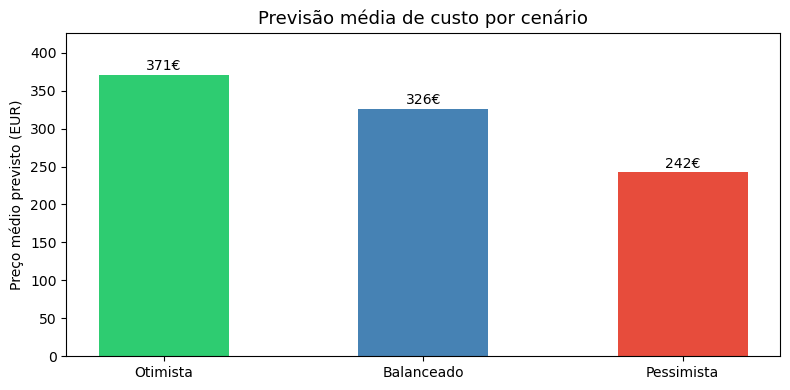

In [102]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
cores = {"Otimista": "#2ecc71", "Balanceado": "steelblue", "Pessimista": "#e74c3c"}
x = range(len(df_cenarios))

bars = ax.bar(df_cenarios["cenario"], df_cenarios["preco_medio_eur"],
              color=[cores[c] for c in df_cenarios["cenario"]], width=0.5)

for bar, val in zip(bars, df_cenarios["preco_medio_eur"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+ 6,
            f"{val:.0f}€", ha="center", fontsize=10)

ax.set_title("Previsão média de custo por cenário", fontsize=13)
ax.set_ylabel("Preço médio previsto (EUR)")
ax.set_ylim(0, df_cenarios["preco_medio_eur"].max() * 1.15)
plt.tight_layout()
plt.show()

O gráfico mostra que o cenário pessimista apresenta um preço médio previsto inferior ao otimista, o que é contra-intuitivo e resulta da limitação descrita acima - o modelo não tem dados suficientes para capturar corretamente o efeito do combustível e do conflito no preço. O valor desta secção está na demonstração da arquitetura da camada de cenários, ou seja, a lógica de substituição de features contextuais sem retreinar o modelo, e não nos valores específicos obtidos neste teste inicial.

#### 8.2. Previsões de duração por cenário

O modelo de duração não inclui features de combustível - estas não são consideradas relevantes para a duração de um voo. Por isso, os cenários de duração variam apenas as features de conflito: `conflict_active`, `flight_cancellations_est` e `airspace_closures`.

Conflito ativo pode aumentar a duração dos voos por desvios de rota, atrasos operacionais e restrições de espaço aéreo. Com apenas 6 meses de dados e pouca variação nas features de conflito, espera-se que o impacto entre cenários seja pequeno, pela mesma razão identificada para o custo.

In [105]:
df_sorted_dur_B = df_model.sort_values("Departure Date").reset_index(drop=True)
n_valid_dur_B = res_duracao_A["oof_preds"].shape[0]
X_base_dur = df_sorted_dur_B[features_duracao_selected].iloc[-n_valid_dur_B:].reset_index(drop=True).copy()

# features de conflito disponiveis no modelo de duracao
features_conflito_dur = ["conflict_active", "flight_cancellations_est", "airspace_closures"]

cenarios_dur = {
    "Otimista": {
        "conflict_active":          0,
        "flight_cancellations_est": 0,
        "airspace_closures":        0,
    },
    "Balanceado": {
        "conflict_active":          base_conflict,   
        "flight_cancellations_est": base_cancel,    
        "airspace_closures":        base_closure,    
    },
    "Pessimista": {
        "conflict_active":          1,
        "flight_cancellations_est": df_model["flight_cancellations_est"].max(),
        "airspace_closures":        df_model["airspace_closures"].max(),
    },
}

resultados_cenarios_dur = []

for nome_cenario, valores in cenarios_dur.items():
    X_cenario_dur = X_base_dur.copy()

    for feat, val in valores.items():
        if feat in X_cenario_dur.columns:
            X_cenario_dur[feat] = val

    X_meta_dur_c = np.hstack([
        res_duracao_A["oof_preds"].astype(np.float64),
        X_cenario_dur.values.astype(np.float64)
    ])
    pred_dur = res_duracao_A["ridge"].predict(X_meta_dur_c)
    pred_dur = pred_dur.clip(min=0)

    resultados_cenarios_dur.append({
        "cenario":              nome_cenario,
        "duracao_media_min":    round(pred_dur.mean(),        1),
        "duracao_mediana_min":  round(np.median(pred_dur),    1),
        "duracao_min_min":      round(pred_dur.min(),         1),
        "duracao_max_min":      round(pred_dur.max(),         1),
    })

df_cenarios_dur = pd.DataFrame(resultados_cenarios_dur)
print("Previsoes de duracao por cenario (em minutos):")
display(df_cenarios_dur)

Previsoes de duracao por cenario (em minutos):


,cenario,duracao_media_min,duracao_mediana_min,duracao_min_min,duracao_max_min
0,Otimista,567.3,552.8,30.1,1597.6
1,Balanceado,567.3,552.8,30.1,1597.6
2,Pessimista,567.3,552.8,30.1,1597.6


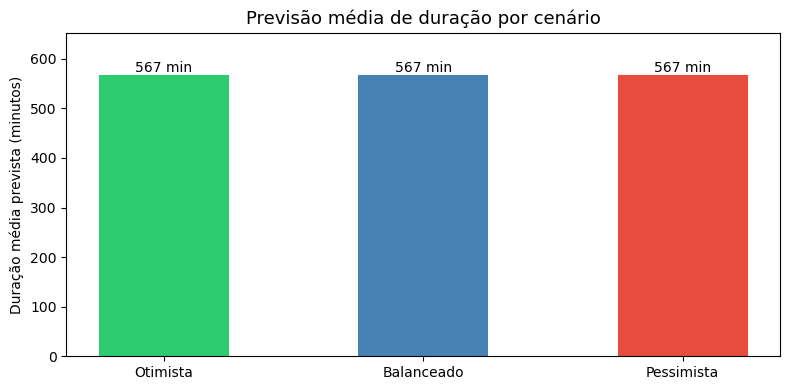

In [107]:
fig, ax = plt.subplots(figsize=(8, 4))
cores = {"Otimista": "#2ecc71", "Balanceado": "steelblue", "Pessimista": "#e74c3c"}

bars = ax.bar(df_cenarios_dur["cenario"], df_cenarios_dur["duracao_media_min"],
              color=[cores[c] for c in df_cenarios_dur["cenario"]], width=0.5)

for bar, val in zip(bars, df_cenarios_dur["duracao_media_min"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6,
            f"{val:.0f} min", ha="center", fontsize=10)

ax.set_title("Previsão média de duração por cenário", fontsize=13)
ax.set_ylabel("Duração média prevista (minutos)")
ax.set_ylim(0, df_cenarios_dur["duracao_media_min"].max() * 1.15)
plt.tight_layout()
plt.show()

Os 3 cenários produzem previsões de duração idênticas (567 min), o que confirma que as features de conflito têm coeficientes praticamente nulos no modelo de duração. A análise dos coeficientes do Ridge comprova esta conclusão. No sistema final, com dados de mais rotas afetadas por restrições de espaço aéreo e com features de clima e atraso histórico disponíveis, os cenários de duração terão impacto real e diferenciado.

### 9. Perfis de decisão

Após as previsões, o sistema aplica uma camada de decisão multiobjetivo. É calculado um score ponderado para cada rota e cenário, com base nas previsões de custo e duração:

$$score = (w_c \times {custo}_{norm}) + (w_t \times {duracao}_{norm})$$

Os valores são normalizados (0 a 1) antes de aplicar os pesos, para que as diferentes escalas (euros vs minutos) não distorçam o score.

Nota: no sistema final o score inclui também o CO2 previsto. Neste teste inicial, com apenas custo e duração disponíveis, o perfil Sustentável não é calculado.

Os quatro perfis e os respectivos pesos são:

| Perfil | w_custo | w_tempo |
|---|---|---|
| Económico | 0.80 | 0.20 |
| Rápido | 0.20 | 0.80 |
| Equilibrado | 0.50 | 0.50 |

#### 9.1. Cálculo dos scores por perfil e cenário

In [77]:
# perfis de decisao (sem CO2 neste teste inicial)
perfis = {
    "Economico":   {"w_custo": 0.80, "w_tempo": 0.20},
    "Rapido":      {"w_custo": 0.20, "w_tempo": 0.80},
    "Equilibrado": {"w_custo": 0.50, "w_tempo": 0.50},
}

# previsoes de duracao por cenario (modelo A - duracao nao tem features externas relevantes)
df_sorted_dur = df_model.sort_values("Departure Date").reset_index(drop=True)
mask_dur_B = ~np.isnan(res_duracao_A["oof_preds"][:,0])
pred_duracao_base = res_duracao_A["y_pred"]  # previsoes base

# normalizar previsoes para [0,1] - necessario para comparar escalas diferentes
from sklearn.preprocessing import MinMaxScaler

resultados_perfis = []

for nome_cenario, valores in cenarios.items():
    # custo previsto para este cenario
    X_cenario = X_base_custo.copy()
    for feat, val in valores.items():
        if feat in X_cenario.columns:
            X_cenario[feat] = val
    X_meta_c = np.hstack([res_custo_B["oof_preds"], X_cenario.values])
    pred_custo_c = res_custo_B["ridge"].predict(X_meta_c)

    # normalizar custo e duracao
    custo_norm   = (pred_custo_c - pred_custo_c.min()) / (pred_custo_c.max() - pred_custo_c.min() + 1e-9)
    duracao_norm = (pred_duracao_base - pred_duracao_base.min()) / (pred_duracao_base.max() - pred_duracao_base.min() + 1e-9)

    # garantir mesmo tamanho
    min_len = min(len(custo_norm), len(duracao_norm))
    custo_norm   = custo_norm[:min_len]
    duracao_norm = duracao_norm[:min_len]

    for nome_perfil, pesos in perfis.items():
        score = pesos["w_custo"] * custo_norm + pesos["w_tempo"] * duracao_norm
        resultados_perfis.append({
            "cenario": nome_cenario,
            "perfil": nome_perfil,
            "score_medio": round(score.mean(), 4),
            "custo_medio_eur": round(pred_custo_c[:min_len].mean(), 2),
            "duracao_media_min": round(pred_duracao_base[:min_len].mean(), 2),
        })

df_perfis = pd.DataFrame(resultados_perfis)
print("Scores por cenario e perfil:")
display(df_perfis)

Scores por cenario e perfil:


,cenario,perfil,score_medio,custo_medio_eur,duracao_media_min
0,Otimista,Economico,0.2282,370.49,567.3
1,Otimista,Rapido,0.3141,370.49,567.3
2,Otimista,Equilibrado,0.2711,370.49,567.3
3,Balanceado,Economico,0.2282,330.50,567.3
4,Balanceado,Rapido,0.3141,330.50,567.3
5,Balanceado,Equilibrado,0.2711,330.50,567.3
6,Pessimista,Economico,0.2282,241.01,567.3
7,Pessimista,Rapido,0.3141,241.01,567.3
8,Pessimista,Equilibrado,0.2711,241.01,567.3


#### 9.2. Visualização dos scores

Um score mais baixo é melhor, pois representa uma rota com custo e/ou duração mais favoráveis segundo o perfil de pesos escolhido. O cenário otimista deve produzir scores menores do que o pessimista em todos os perfis.

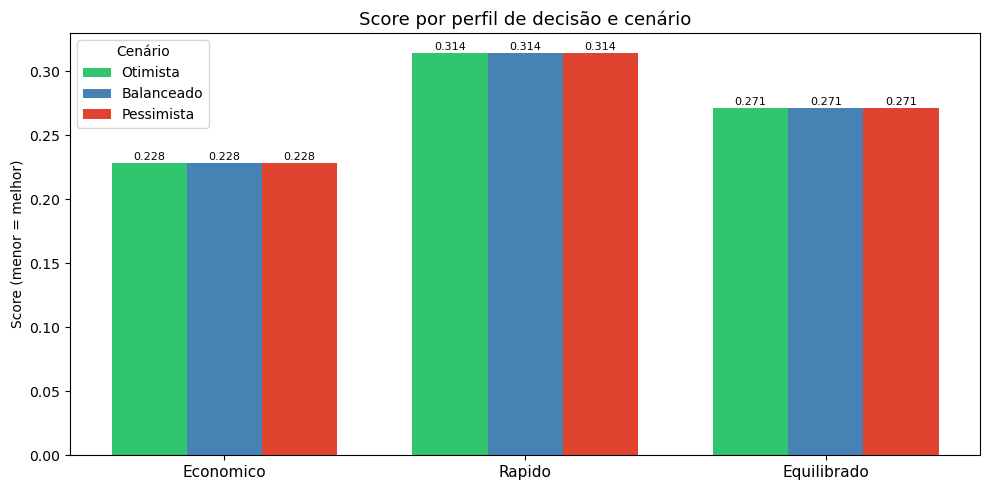

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))

perfil_names = df_perfis["perfil"].unique()
cenario_names = df_perfis["cenario"].unique()
x = np.arange(len(perfil_names))
width = 0.25
cores_cen = {"Otimista": "#32c56f", "Balanceado": "steelblue", "Pessimista": "#e14331"}

for i, cenario in enumerate(cenario_names):
    dados = df_perfis[df_perfis["cenario"] == cenario]
    scores = [dados[dados["perfil"] == p]["score_medio"].values[0] for p in perfil_names]
    bars = ax.bar(x + i*width, scores, width, label=cenario, color=cores_cen[cenario])
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(perfil_names, fontsize=11)
ax.set_ylabel("Score (menor = melhor)")
ax.set_title("Score por perfil de decisão e cenário", fontsize=13)
ax.legend(title="Cenário")
plt.tight_layout()
plt.show()

Os scores variam entre perfis:
- **Económico (0.228)** - score mais baixo porque dá 80% de peso ao custo. Como o custo normalizado é baixo face à duração normalizada, o score fica menor. É o perfil que "penaliza menos" neste dataset.
- **Equilibrado (0.271)** - score intermédio, como esperado com pesos iguais.
- **Rápido (0.314)** - score mais alto porque dá 80% de peso à duração. A duração média de 567 minutos (aproximadamente 9h30) normalizada resulta num valor mais alto, o que eleva o score.

Os scores são idênticos nos 3 cenários porque a duração prevista não varia entre cenários e as diferenças de custo são insuficientes para alterar os scores normalizados de forma significativa. No sistema final, com previsões de custo, duração e CO2 que respondem corretamente aos cenários, os perfis de decisão produzirão scores diferenciados por cenário - o que é o objetivo da camada de decisão multiobjetivo.

### 10. Limitações deste notebook

Esta secção regista as principais limitações do teste inicial, relevantes para interpretar os resultados e orientar a fase seguinte.

**Cobertura geográfica limitada**:
O `flights.csv` cobre apenas 6 aeroportos domésticos nos EUA (BOS, JFK, LAS, LAX, ORD, SFO). O sistema final deverá cobrir rotas internacionais e multimodais, pelo que os resultados não são diretamente generalizáveis.

**Modo de transporte único**:
Todos os registos correspondem a voos. A feature "modo de transporte" não tem variação real neste teste.

**Distância aproximada (Haversine)**:
A distância foi calculada em linha reta pela fórmula de Haversine. A distância real percorrida pode ser superior, especialmente em rotas com desvios por conflitos ou restrições de espaço aéreo.

**Encoding de aeroportos - limitação do label encoding**:
Os aeroportos foram codificados com label encoding (um número inteiro por aeroporto), que evita data leakage mas não captura relações de similaridade entre aeroportos. No sistema final, o target encoding correto será aplicado dentro de cada fold do walk-forward: calcula-se a média do preço ou duração por aeroporto apenas com os dados de treino, e aplica-se esse valor aos dados de teste, sem expor informação futura ao modelo.

**Cobertura temporal parcial**:
O `flights.csv` cobre apenas julho a dezembro de 2024 (6 meses). A validação walk-forward fica limitada e o modelo não observa sazonalidade de início de ano.

**Granularidade mensal dos dados externos**:
Os datasets de combustível, conflitos e câmbio têm granularidade mensal. Todos os voos do mesmo mês recebem os mesmos valores externos, o que subestima a variação intra-mensal destes fatores.

**Dados climáticos não integrados**:
Os ficheiros climáticos disponíveis (formato `.nc`) cobrem a Europa e não os aeroportos dos EUA presentes neste dataset. A integração climática fica reservada para o sistema final com dados de rotas europeias e internacionais.

**Features ausentes nesta fase**:
Não foi calculado neste teste: feriados nacionais, atraso histórico por rota, risco de greve, coeficiente de não-linearidade e Erro Rolling 7 dias (este último só pode ser calculado após os primeiros treinos do modelo).

**Fusos horários - a confirmar no sistema final**:
As datas de partida e chegada foram tratadas assumindo que estão no mesmo fuso horário. Os 6 aeroportos do dataset cobrem 4 fusos horários diferentes nos EUA (Eastern, Central, Mountain e Pacific), pelo que as horas locais podem não ser diretamente comparáveis entre si. Isto afeta a interpretação do `dep_hour` e potencialmente o cálculo do `Duration_min`. No sistema final, as datas devem ser convertidas para UTC antes de qualquer cálculo temporal, e deve verificar-se se há registos com Duration_min negativa ou implausível por rota.